In [1]:
from csv_reader import read_csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from aux import format_plot
from copy import deepcopy as copy
import os
from scipy import stats
from functools import partial

plt.rcParams['font.family'] = 'Helvetica'

BATCH_SIZE = 1
PARAMS_START = 2 + BATCH_SIZE
N_PAIRWISE_RULES_PER_TYPE = 12 * 2
N_SUMMED_WEIGHT_RULES_PER_TYPE = 4
N_THREE_FACTOR_RULES_PER_TYPE = 8
N_RULES = 3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE) + 2 * N_THREE_FACTOR_RULES_PER_TYPE
N_PAIRWISE_TIMECONSTS = 12
N_TIMECONSTS = N_PAIRWISE_TIMECONSTS + 32
tf_timeconst_start = N_RULES + N_PAIRWISE_TIMECONSTS
N_PARAMS = N_RULES + N_TIMECONSTS
three_factor_start = 3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE)

R_RESCALING = 5
R_EXP_RESCALING = 5
W_RESCALING = 1
THREE_FACTOR_RESCALING = 2
SUMMED_WEIGHT_RESCALING = 0.05 # formerly 0.05

In [2]:
rule_names = [ # Define labels for all rules to be run during simulations
	r'',
	r'$y$',
	r'$x$',
	r'$y^2$',
	r'$x^2$',
	r'$y^3$',
	r'$x^3$',
	r'$y^4$',
	r'$x^4$',
	r'$x \, y$',
	r'$x \, \tilde{y}$',
	r'$\tilde{x} \, y$',

	r'$w$',
	r'$w y$',
	r'$w x$',
	r'$w y^2$',
	r'$w x^2$',
	r'$w y^3$',
	r'$w x^3$',
	r'$w y^4$',
	r'$w x^4$',
	r'$w x \, y$',
	r'$w x \, \tilde{y}$',
	r'$w \tilde{x} \, y$',

	r'$\sum_k w_{kj}$',
    r'$w \sum_k w_{kj}$',
	r'$\sum_k w_{ik}$',
    r'$w \sum_k w_{ik}$',
]

rule_names = [
	[r'$HD \rightarrow HD$ ' + r_name for r_name in rule_names],
	[r'$HD \rightarrow HR$ ' + r_name for r_name in rule_names],
	[r'$HR \rightarrow HD$ ' + r_name for r_name in rule_names],
]

rule_names_tripartite = [
	r'$\tilde{y}, z \sim y$',
	r'$\tilde{x}, z \sim y$',
	r'$x \tilde{y}, z \sim y$',
	r'$\tilde{x} y, z \sim y$',

	r'$w \tilde{y}, z \sim y$',
	r'$w \tilde{x}, z \sim y$',
	r'$w x \tilde{y}, z \sim y$',
	r'$w \tilde{x} y, z \sim y$',
]

rule_names += [
	[r'$HD \rightarrow HD, HR \sim HD$' + r_name for r_name in rule_names_tripartite],
	[r'$HR \rightarrow HD, HD \sim HD$' + r_name for r_name in rule_names_tripartite],
]


rule_names = [r for rs in rule_names for r in rs]
rule_names = np.array(rule_names, dtype=object)


In [3]:
for i, rn in enumerate(rule_names):
    print(i, rn)

0 $HD \rightarrow HD$ 
1 $HD \rightarrow HD$ $y$
2 $HD \rightarrow HD$ $x$
3 $HD \rightarrow HD$ $y^2$
4 $HD \rightarrow HD$ $x^2$
5 $HD \rightarrow HD$ $y^3$
6 $HD \rightarrow HD$ $x^3$
7 $HD \rightarrow HD$ $y^4$
8 $HD \rightarrow HD$ $x^4$
9 $HD \rightarrow HD$ $x \, y$
10 $HD \rightarrow HD$ $x \, \tilde{y}$
11 $HD \rightarrow HD$ $\tilde{x} \, y$
12 $HD \rightarrow HD$ $w$
13 $HD \rightarrow HD$ $w y$
14 $HD \rightarrow HD$ $w x$
15 $HD \rightarrow HD$ $w y^2$
16 $HD \rightarrow HD$ $w x^2$
17 $HD \rightarrow HD$ $w y^3$
18 $HD \rightarrow HD$ $w x^3$
19 $HD \rightarrow HD$ $w y^4$
20 $HD \rightarrow HD$ $w x^4$
21 $HD \rightarrow HD$ $w x \, y$
22 $HD \rightarrow HD$ $w x \, \tilde{y}$
23 $HD \rightarrow HD$ $w \tilde{x} \, y$
24 $HD \rightarrow HD$ $\sum_k w_{kj}$
25 $HD \rightarrow HD$ $w \sum_k w_{kj}$
26 $HD \rightarrow HD$ $\sum_k w_{ik}$
27 $HD \rightarrow HD$ $w \sum_k w_{ik}$
28 $HD \rightarrow HR$ 
29 $HD \rightarrow HR$ $y$
30 $HD \rightarrow HR$ $x$
31 $HD \rightarrow 

In [4]:
DATA_PATHS_NO_HET_SHORT_N5 = [
    'sims_out/n5_short_min_pactive_0p25_diag_test_001051_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:26:56.079474_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_test_001052_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:26:56.227715_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_test_001053_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:26:55.864791_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_test_001054_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:26:55.898742_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_test_001055_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:26:55.942330_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_test_001056_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:27:00.512577_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_test_001057_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:27:00.717151_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_test_001058_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:27:00.717145_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_test_001059_0.3_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-21_12:27:00.741484_run_None',
]

DATA_PATHS_HET_SHORT_N5 = [
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001061_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:13:15.294098_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001062_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:13:15.294098_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001063_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:13:15.294095_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001064_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:12:59.693702_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001065_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:12:59.693703_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001066_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:12:59.693704_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001067_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:12:59.693701_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001068_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:12:59.693690_run_None',
    'sims_out/n5_short_min_pactive_0p25_diag_small_bump_test_001069_0.3_inp_0.27_het_0.2_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-24_12:12:59.693694_run_None',
]

DATA_PATHS_NO_HET_LONG_N5 = [
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001100_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:23.644770_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001101_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.297833_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001102_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:18.591026_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001103_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.167434_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001105_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.167432_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001106_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.547200_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001107_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.547200_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001108_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.547200_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001110_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.025293_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001111_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.025289_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001112_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:22.025292_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001118_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:23.162271_run_None',
    'sims_out/n5_long_min_pactive_0p25_diag_small_bump_test_001119_1.0_inp_0.27_het_0_shift_1_TH_0_STD_EXPL_0.001__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2026-01-02_12:10:23.318062_run_None',
]

DATA_PATHS_NO_HET_SHORT_2D = [
    'sims_out/2D_short_reverted_test_000850_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567091_run_None',
    'sims_out/2D_short_reverted_test_000851_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567095_run_None',
    'sims_out/2D_short_reverted_test_000852_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:02.567326_run_None',
    'sims_out/2D_short_reverted_test_000854_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:49.971242_run_None',
    'sims_out/2D_short_reverted_test_000855_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:06.935493_run_None',
    'sims_out/2D_short_reverted_test_000856_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:56:06.935488_run_None',
    'sims_out/2D_short_reverted_test_000857_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:51.875753_run_None',
    'sims_out/2D_short_reverted_test_000858_time_0.3_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_11:55:51.915822_run_None',
]

DATA_PATHS_NO_HET_LONG_2D = [
    'sims_out/2D_long_reverted_test_000866_time_1.0_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-14_12:27:15.036861_run_None',
    'sims_out/2D_long_reverted_test_000867_time_1.0_inp_0.27_het_0_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-14_12:27:12.464502_run_None',
]

DATA_PATHS_HET_SHORT_2D = [
    'sims_out/2D_short_reverted_test_000755_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_13:33:23.140584_run_None',
    'sims_out/2D_short_reverted_test_000756_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_13:33:19.544611_run_None',
    'sims_out/2D_short_reverted_test_000758_time_0.3_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-11_13:33:19.710490_run_None',
]

DATA_PATHS_HET_LONG_2D = [
    'sims_out/2D_long_reverted_test_000806_time_1.0_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-14_12:41:29.302142_run_None',
    'sims_out/2D_long_reverted_test_000808_time_1.0_inp_0.27_het_0.2_2D_1_TH_0_STD_EXPL_None__L1_PENALTY_5e-07_ACT_PEN_50.0_CHANGEP_0.0_SEED_2000_2025-12-14_12:41:29.302142_run_None',
]

In [5]:
def load_coefs(df):
    o = read_csv(os.path.join(df, 'train_data.csv'), read_header=False)
    coefs = np.array(o.iloc[0, PARAMS_START: PARAMS_START + N_PARAMS])
    return coefs

def load_all_coefs(dfs):
    return [load_coefs(df) for df in dfs]

In [6]:
def plot_heatmap(x1, x2, f, v=None, axs=None, fig=None, add_colorbar=False):
    X1, X2 = np.meshgrid(x1, x2, indexing='ij')
    w_ij_dot = f(X1, X2)

    cmap = sns.diverging_palette(250, 10, s=100, l=55, as_cmap=True)

    m = np.abs(w_ij_dot).max()
    v = m if v is None else v
    norm = TwoSlopeNorm(vmin=-v, vcenter=0, vmax=v)

    if axs is None:
        fig, axs = plt.subplots(1, 1, figsize=(3, 3))

    im = axs.matshow(w_ij_dot, cmap=cmap, norm=norm)

    if add_colorbar:
        cbar = fig.colorbar(im, ax=axs)
        format_plot(cbar.ax)

    format_plot(axs, axislabelsize=16, ticklabelsize=12)

    return im, m


# Function
def presyn_f(a, w_ij, coefs, include_const=True):
    a *= R_RESCALING
    w_ij *= W_RESCALING
    return (
        coefs[0] * include_const
        + coefs[2] * a
        + coefs[4] * a**2
        + coefs[6] * a**3
        + coefs[8] * a**4
        + w_ij * (
            coefs[12] * include_const
            + coefs[14] * a
            + coefs[16] * a**2
            + coefs[18] * a**3
            + coefs[20] * a**4
        )
    )
    

def postsyn_f(a, w_ij, coefs, include_const=True):
    a *= R_RESCALING
    w_ij *= W_RESCALING
    return (
        coefs[0] * include_const
        + coefs[1] * a
        + coefs[3] * a**2
        + coefs[5] * a**3
        + coefs[7] * a**4
        + w_ij * (
            coefs[12] * include_const
            + coefs[13] * a
            + coefs[15] * a**2
            + coefs[17] * a**3
            + coefs[19] * a**4
        )
    )
    

def pairwise_f(a_pre, a_post, w_ij, t_lag, coefs, rate=False):
    w_ij *= W_RESCALING
    if rate:
        return (
            coefs[9] * a_pre * a_post * R_RESCALING**2
            + coefs[10] * a_pre * a_post * R_RESCALING * R_EXP_RESCALING * coefs[N_RULES + 0]
            + coefs[11] * a_pre * a_post * R_RESCALING * R_EXP_RESCALING * coefs[N_RULES + 1]
            + w_ij * (
                coefs[21] * a_pre * a_post * R_RESCALING**2
                + coefs[22] * a_pre * a_post * R_RESCALING * R_EXP_RESCALING * coefs[N_RULES + 2]
                + coefs[23] * a_pre * a_post * R_RESCALING * R_EXP_RESCALING * coefs[N_RULES + 3]
            )
        )
    else:
        return (
            coefs[9] * a_pre * a_post * R_RESCALING**2 * np.isclose(t_lag, 0)
            + coefs[10] * a_pre * a_post * R_RESCALING * R_EXP_RESCALING * np.where(t_lag < 0, np.exp(t_lag / coefs[N_RULES + 0]), 0)
            + coefs[11] * a_pre * a_post * R_RESCALING * R_EXP_RESCALING * np.where(t_lag > 0, np.exp(-t_lag / coefs[N_RULES + 1]), 0)
            + w_ij * (
                coefs[21] * a_pre * a_post * R_RESCALING**2 * np.isclose(t_lag, 0)
                + coefs[22] * a_pre * a_post * R_RESCALING * R_EXP_RESCALING * np.where(t_lag < 0, np.exp(t_lag / coefs[N_RULES + 2]), 0)
                + coefs[23] * a_pre * a_post * R_RESCALING * R_EXP_RESCALING * np.where(t_lag > 0, np.exp(-t_lag / coefs[N_RULES + 3]), 0)
            )
        )

def third_factor(tau, z, t_lag):
    return z * THREE_FACTOR_RESCALING * np.where(t_lag >= 0, np.exp(-t_lag / tau), 0)

# def three_factor(a1, a2, z, w_ij, t_lag_1, t_lag_2, t_lag_z, coefs):
#     w_ij *= W_RESCALING
#     tf = third_factor(np.array([
#         coefs[tf_timeconst_start + 1],
#         coefs[tf_timeconst_start + 3],
#         coefs[tf_timeconst_start + 5],
#         coefs[tf_timeconst_start + 7],
#         coefs[tf_timeconst_start + 9],
#         coefs[tf_timeconst_start + 11],
#         coefs[tf_timeconst_start + 13],
#         coefs[tf_timeconst_start + 15],
#     ]), z, t_lag_z)
    
#     f = coefs[three_factor_start + 0] * a2 * R_EXP_RESCALING * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[tf_timeconst_start + 0]), 0) * tf[0] \
#     + coefs[three_factor_start + 1] * a1 * R_EXP_RESCALING * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[tf_timeconst_start+ 2]), 0) * tf[1] \
#     + coefs[three_factor_start + 2] * a1 * a2 * R_EXP_RESCALING * R_RESCALING * (np.abs(t_lag_1) < 0.1e-3) * np.where(tf_timeconst_start >= 0, np.exp(-t_lag_2 / coefs[tf_timeconst_start + 4]), 0) * tf[2] \
#     + coefs[three_factor_start + 3] * a1 * a2 * R_EXP_RESCALING * R_RESCALING * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[tf_timeconst_start + 6]), 0) * (np.abs(t_lag_2) < 0.1e-3) *  tf[3] \
#     + coefs[three_factor_start + 4] * w_ij * a2 * R_EXP_RESCALING * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[tf_timeconst_start + 8]), 0) * tf[4] \
#     + coefs[three_factor_start + 5] * w_ij * a1 * R_EXP_RESCALING * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[tf_timeconst_start + 10]), 0) * tf[5] \
#     + coefs[three_factor_start + 6] * w_ij * a1 * a2 * R_EXP_RESCALING * R_RESCALING * (np.abs(t_lag_1) < 0.1e-3) * np.where(t_lag_2 >= 0, np.exp(-t_lag_2 / coefs[tf_timeconst_start + 12]), 0) * tf[6] \
#     + coefs[three_factor_start + 7] * w_ij * a1 * a2 * R_EXP_RESCALING * R_RESCALING * np.where(t_lag_1 >= 0, np.exp(-t_lag_1 / coefs[tf_timeconst_start + 14]), 0) * (np.abs(t_lag_2) < 0.1e-3) * tf[7]
#     return f

def three_factor_z_post(a_post, z, w_ij, t_lag, coefs):
    # t_lag here is the lag between z and t_pre, so t_pre - t_z
    # if lag is positive, use z's time const
    # if lag is negative, use t_pre's time const
    z *= THREE_FACTOR_RESCALING
    a_post *= R_EXP_RESCALING
    w_ij *= W_RESCALING
    
    f  = coefs[three_factor_start + 0] * a_post * z * np.where(t_lag >= 0, np.exp(-t_lag / coefs[tf_timeconst_start + 1]), np.exp(t_lag / coefs[tf_timeconst_start + 0])) \
        + coefs[three_factor_start + 4] * a_post * z * w_ij * np.where(t_lag >= 0, np.exp(-t_lag / coefs[tf_timeconst_start + 9]), np.exp(t_lag / coefs[tf_timeconst_start + 8]))
    return f

def three_factor_z_pre(a_pre, z, w_ij, t_lag, coefs):
    # t_lag here is the lag between z and t_post, so t_post - t_z
    # if lag is positive, use z's time const
    # if lag is negative, use t_post's time const
    z *= THREE_FACTOR_RESCALING
    a_pre *= R_EXP_RESCALING
    w_ij *= W_RESCALING
    
    f  = coefs[three_factor_start + 2] * a_pre * z * np.where(t_lag >= 0, np.exp(-t_lag / coefs[tf_timeconst_start + 5]), np.exp(t_lag / coefs[tf_timeconst_start + 4])) \
        + coefs[three_factor_start + 6] * a_pre * z * w_ij * np.where(t_lag >= 0, np.exp(-t_lag / coefs[tf_timeconst_start + 13]), np.exp(t_lag / coefs[tf_timeconst_start + 12]))
    return f

def three_factor_pre_post_z(a_pre, a_post, z, w_ij, t_lag_post_pre, t_lag_post_z, coefs):
    taus = [
        coefs[tf_timeconst_start + 3],
        coefs[tf_timeconst_start + 7],
        coefs[tf_timeconst_start + 11],
        coefs[tf_timeconst_start + 15],
    ]
    z *= THREE_FACTOR_RESCALING
    a_pre *= R_EXP_RESCALING
    a_post *= R_RESCALING
    w_ij *= W_RESCALING
    tf = [
        third_factor(taus[0], z, t_lag_post_z),
        third_factor(taus[1], z, t_lag_post_z),
        third_factor(taus[2], z, -t_lag_post_pre + t_lag_post_z),
        third_factor(taus[3], z, -t_lag_post_pre + t_lag_post_z),
    ]

    f = coefs[three_factor_start + 1] * a_pre * a_post * np.where(t_lag_post_pre < 0, np.exp(t_lag_post_pre / coefs[tf_timeconst_start + 2]), 0) * tf[0] \
        + coefs[three_factor_start + 3] * a_pre * a_post * np.where(t_lag_post_pre < 0, np.exp(t_lag_post_pre / coefs[tf_timeconst_start + 6]), 0) * tf[1] \
        + coefs[three_factor_start + 5] * a_pre * a_post * w_ij * np.where(t_lag_post_pre >= 0, np.exp(-t_lag_post_pre / coefs[tf_timeconst_start + 10]), 0) * tf[2] \
        + coefs[three_factor_start + 7] * a_pre * a_post * w_ij * np.where(t_lag_post_pre >= 0, np.exp(-t_lag_post_pre / coefs[tf_timeconst_start + 14]), 0) * tf[3] \

    return f

def presyn_weight_bound(w1, w2, coefs):
    summed = (w1 + w2) * SUMMED_WEIGHT_RESCALING
    return (
        coefs[0]
        + w1 * coefs[12] * W_RESCALING
        + coefs[24] * summed
        + w1 * coefs[25] * summed
    )

def postsyn_weight_bound(w1, w2, coefs):
    summed = (w1 + w2) * SUMMED_WEIGHT_RESCALING
    return (
        coefs[0]
        + w1 * coefs[12] * W_RESCALING
        + coefs[26] * summed
        + w1 * coefs[27] * summed
    )

In [7]:
def plot_all(a_pre, a_post, z, t_lag_post_z, coefs, axs, fig,
             set_label=True, v=None):

    w_ij = np.linspace(0, 6, 101)
    t_lag = np.linspace(-0.02, 0.02, 101)

    im, m = plot_heatmap(
        w_ij,
        t_lag,
        lambda w, t: (
            pairwise_f(a_pre, a_post, w, t, coefs)
            + postsyn_f(a_post, w, coefs, include_const=False)
            + presyn_f(a_pre, w, coefs)
            + three_factor_z_pre(a_pre, z, w, t_lag_post_z - t, coefs)
            + three_factor_z_post(a_post, z, w, t_lag_post_z, coefs)
            + three_factor_pre_post_z(
                a_pre, a_post, z, w, t, t_lag_post_z, coefs
            )
        ),
        v=v,
        axs=axs,
        fig=fig,
        add_colorbar=False,
    )

    if set_label:
        axs.set_ylabel('W')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm pre}$')

    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 100], [0, 6])

    return im, m

In [8]:
def plot_rules_under_input(coefs, z=0, t_lag_post_z=0, v=None):
    fig, axs = plt.subplots(3, 3, sharex=True, sharey=True, constrained_layout=True, figsize=(5, 4))

    conds = [(a_pre, a_post)
             for a_pre in [0, 0.2, 0.4]
             for a_post in [0, 0.2, 0.4]]

    mappable = None
    all_maxes = []

    for i, (a_pre, a_post) in enumerate(conds):
        ax = axs[i // 3, i % 3]

        im, m = plot_all(
            a_pre, a_post, z, t_lag_post_z,
            coefs, ax, fig, set_label=False, v=v,
        )
        all_maxes.append(m)

        if mappable is None:
            mappable = im

        if i // 3 != 2:
            ax.tick_params(labelbottom=False)
            
        if i == 0:
            ax.set_title(
                rf'$r_j$, $r_i$ = ({a_pre}, {a_post})'
            )
        else:
            ax.set_title(
                f'({a_pre}, {a_post})'
            )

        ax.tick_params(
            axis="x",
            top=False,
            labeltop=False,
            bottom=True,
            labelbottom=(i // 3 == 2),
        )
        ax.invert_yaxis()

    axs[1, 0].set_ylabel(r'$w_{ij}$')
    axs[2, 1].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')

    # for ax in np.flatten(axs):
    #     ax.set_

    cbar = fig.colorbar(
        mappable,
        ax=axs,
        location="right",
        fraction=0.03,
        pad=0.08,
        shrink=0.6,
    )
    format_plot(cbar.ax)
    format_plot(axs)

    return fig, axs

In [9]:
def test_time_lags(dfs, a_pre, a_post, z, w_ij, ylim=None):

    def compute_dw(t_lag_post_z, t, coefs):
        return (
            pairwise_f(a_pre, a_post, w_ij, t, coefs)
            + postsyn_f(a_post, w_ij, coefs, include_const=False)
            + presyn_f(a_pre, w_ij, coefs)
            + three_factor_z_pre(a_pre, z, w_ij, t_lag_post_z - t, coefs)
            + three_factor_z_post(a_post, z, w_ij, t_lag_post_z, coefs)
            + three_factor_pre_post_z(
                a_pre, a_post, z, w_ij, t, t_lag_post_z, coefs
            )
        )

    t_post_pre_lags = np.array([-1e-3, -1e-3, 1e-3, 1e-3])
    t_post_z_lags = np.array([-1e-3, 1e-3, 1e-3, -1e-3])

    all_dw = []

    for df in dfs:
        coefs = load_coefs(df)
        compute_dw_for_coefs = np.vectorize(partial(compute_dw, coefs=coefs))
        dw = compute_dw_for_coefs(t_post_z_lags, t_post_pre_lags)   
        all_dw.append(dw)
    all_dw = np.array(all_dw)

    fig, axs = plt.subplots(1, 1, sharex=True, sharey=True, constrained_layout=True, figsize=(3.5, 1.6))
    for i in range(all_dw.shape[0]):
        axs.plot(np.arange(all_dw.shape[1]), all_dw[i, :], color='#4188bf', lw=0.5, alpha=0.4)
        axs.scatter(np.arange(all_dw.shape[1]), all_dw[i, :], facecolor='none', edgecolor='#4188bf', s=50)

    def transform_lags_to_labels(post_pre_lag, post_z_lag):
        return f'({int(post_pre_lag * 1000)}, {int(post_z_lag * 1000)})'

    axs.set_xticks(np.arange(4), [transform_lags_to_labels(*x) for x in zip(t_post_pre_lags, t_post_z_lags)])
    axs.set_xlabel(r'($\Delta t_{ij}, \, \Delta t_{iz}$) [ms, ms]')
    axs.set_ylabel(r'$\Delta w_{ij}$')

    if ylim is not None:
        axs.set_ylim(*ylim)

    format_plot(axs)

    return fig

In [10]:
def plot_all_time_lags_only_curves(a_pre, a_post, z, w_ij, coefs, set_label=True, v=None):

    t_lag = np.linspace(-0.02, 0.02, 101)
    t_lag_post_zs = np.linspace(-0.02, 0.02, 11)

    fig, ax = plt.subplots(1, 1, figsize=(1.5, 1.5))

    def compute_dw(t_lag_post_z, t):
        return (
            pairwise_f(a_pre, a_post, w_ij, t, coefs)
            + postsyn_f(a_post, w_ij, coefs, include_const=False)
            + presyn_f(a_pre, w_ij, coefs)
            + three_factor_z_pre(a_pre, z, w_ij, t_lag_post_z - t, coefs)
            + three_factor_z_post(a_post, z, w_ij, t_lag_post_z, coefs)
            + three_factor_pre_post_z(
                a_pre, a_post, z, w_ij, t, t_lag_post_z, coefs
            )
        )

    # --- diverging colormap setup ---
    cmap = plt.get_cmap("RdYlBu_r")

    vmax = np.max(np.abs(t_lag_post_zs))
    norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    for t_lag_post_z in t_lag_post_zs:
        dws = compute_dw(t_lag_post_z, t_lag)
        color = cmap(norm(t_lag_post_z))
        ax.plot(t_lag, dws, color=color, linewidth=2)

    # --- colorbar ---
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(r"$\Delta t_{\mathrm{post}-z}$")

    ax.set_xlabel(r"$\Delta t$")
    ax.set_ylabel(r"$\Delta w$")

    format_plot(ax)
    format_plot(cbar.ax)

In [11]:
def plot_all_time_lags_only(a_pre, a_post, z, w_ij, coefs, axs, fig, set_label=True, v=None):

    t_lag = np.linspace(-0.02, 0.02, 101)
    t_lag_post_z = np.linspace(-0.02, 0.02, 101)

    im, m = plot_heatmap(
        t_lag_post_z,
        t_lag,
        lambda t_lag_post_z, t: (
            pairwise_f(a_pre, a_post, w_ij, t, coefs)
            + postsyn_f(a_post, w_ij, coefs, include_const=False)
            + presyn_f(a_pre, w_ij, coefs)
            + three_factor_z_pre(a_pre, z, w_ij, t_lag_post_z - t, coefs)
            + three_factor_z_post(a_post, z, w_ij, t_lag_post_z, coefs)
            + three_factor_pre_post_z(
                a_pre, a_post, z, w_ij, t, t_lag_post_z, coefs
            )
        ),
        v=v,
        axs=axs,
        fig=fig,
        add_colorbar=False,
    )

    if set_label:
        axs.set_xlabel(r'$t_{\rm z} - t_{\rm post}$')
        axs.set_xlabel(r'$t_{\rm post} - t_{\rm pre}$')

    axs.set_xticks([0, 50, 100], [-20, 0, 20])
    axs.set_yticks([0, 50, 100], [-20, 0, 20])

    return im, m


In [12]:
def plot_rules_vary_z(coefs, a_pre=0.2, a_post=0.2, z_max=1, z_min=0, w_ij=4, v=None, scale=1):
    fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, constrained_layout=True, figsize=(5 * scale, 4 * scale))

    conds = np.linspace(z_min, z_max, 3)
    mappable = None
    
    for i, z in enumerate(conds):
        ax = axs[i]

        im, m = plot_all_time_lags_only(
            a_pre, a_post, z, w_ij,
            coefs, ax, fig, set_label=False, v=v,
        )
        # all_maxes.append(m)

        if mappable is None:
            mappable = im

        ax.tick_params(
            axis="x",
            top=False,
            labeltop=False,
            bottom=True,
            labelbottom=True,
        )
        ax.invert_yaxis()

    axs[0].set_ylabel(r'$t_{\rm post} - t_{\rm z}$ (ms)')
    axs[1].set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
        
    cbar = fig.colorbar(
        mappable,
        ax=axs,
        location="right",
        fraction=0.03,
        pad=0.08,
        shrink=0.2,
    )
    format_plot(cbar.ax)
    format_plot(axs)
    return fig, axs

In [13]:
def plot_pairwise_kernel(coefs, a_pre, a_post, w_ij, axs, t_lag_post_z=0, z=0, color=None):
    def compute_pairwise(t):
        return (
            pairwise_f(a_pre, a_post, w_ij, t, coefs)
            + postsyn_f(a_post, w_ij, coefs, include_const=False)
            + presyn_f(a_pre, w_ij, coefs)
            + three_factor_z_pre(a_pre, z, w_ij, t_lag_post_z - t, coefs)
            + three_factor_z_post(a_post, z, w_ij, t_lag_post_z, coefs)
            + three_factor_pre_post_z(
                a_pre, a_post, z, w_ij, t, t_lag_post_z, coefs
            )
        )

    t = np.linspace(-20e-3, 20e-3, 1001)
    kwargs = {}
    if color is not None:
        kwargs['color'] = color
    axs.plot(t * 1000, compute_pairwise(t), **kwargs)
    

In [14]:
def plot_kernels_across_weight(dfs, zs=[0], t_lag_post_z=0, save_path=None):
    for i_df, df in enumerate(dfs):
        fig, axs = plt.subplots(
            len(zs), 5, sharex=True, sharey=True,
            constrained_layout=True, figsize=(1.5 * 5, 1 * len(zs))
        )
    
        coefs = load_coefs(df)
        a_pre = 0.2
        a_post = 0.2
        w_ij = np.linspace(0, 3, 5)
    
        # Colormap + normalization
        cmap = sns.color_palette("Blues", as_cmap=True)
        cmap = sns.color_palette('ch:start=.2,rot=-.3', as_cmap=True)
        norm = mpl.colors.Normalize(vmin=w_ij.min(), vmax=w_ij.max())

        for i_z, z in enumerate(zs):
    
            for i_w, w in enumerate(w_ij):
                plot_pairwise_kernel(
                    coefs,
                    a_pre,
                    a_post,
                    w,
                    axs[i_z, i_w],
                    z=z,
                    t_lag_post_z=t_lag_post_z,
                    color=cmap(norm(w)),
                )
    
        axs[-1, 5 // 2].set_xlabel(r'$\Delta t_{ij}$ (ms)')
        axs[0, 0].set_ylabel(
            r'$\dot{W}_{ij}(\Delta t_{ij})$'
        )
    
        # ---- Colorbar ----
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])  # required for older mpl versions
    
        cbar = fig.colorbar(
            sm,
            ax=axs[-1, -1],
            pad=0.02,
            fraction=0.5,
        )
        cbar.set_label(r'$w_{ij}$')
    
        format_plot(axs)
        format_plot(cbar.ax)

        if save_path:
            fig.savefig(save_path + f'_kernels_across_weight_{i_df}.svg')

In [15]:
def plot_kernel_across_w(coefs, w_ij, t_lag, a_pre, a_post, z, axs, t_lag_post_z=0, color=None, jitter=0):
    def compute_pairwise(w_ij, t_lag):
        w_ij = copy(w_ij)
        return (
            pairwise_f(a_pre, a_post, w_ij, t_lag, coefs)
            + postsyn_f(a_post, w_ij, coefs, include_const=False)
            + presyn_f(a_pre, w_ij, coefs)
            + three_factor_z_pre(a_pre, z, w_ij, t_lag_post_z - t_lag, coefs)
            + three_factor_z_post(a_post, z, w_ij, t_lag_post_z, coefs)
            + three_factor_pre_post_z(
                a_pre, a_post, z, w_ij, t_lag, t_lag_post_z, coefs
            )
        )

    cp_vec = np.vectorize(compute_pairwise)
    
    def compute_kernel_asym(w, t_lag):
        t = np.linspace(0, t_lag, 100)
        return np.array([
            cp_vec(w_val, t).sum() - cp_vec(w_val, -t).sum()
            for w_val in w
        ])
    kwargs = {}
    if color is not None:
        kwargs['color'] = color
    kernel_asyms = compute_kernel_asym(w_ij, t_lag)
    axs.plot(w_ij, kernel_asyms, alpha=0.15, **kwargs)
    axs.scatter(
        [w_ij[0] + np.random.normal(scale=jitter), w_ij[-1] + np.random.normal(scale=jitter)],
        [
            kernel_asyms[0],
            kernel_asyms[-1],
        ],
        marker='o',
        s=50,
        facecolor='none',
        edgecolor=color,
    )

    return kernel_asyms

In [16]:
def plot_all_kernels_across_w(
    dfs, w_ij, t_lags,
    a_pre=0.2, a_post=0.2, z=0,
    ylim=None, scatter_color='#4188bf',
    box_color='black', jitter=0,
):
    scale = 1.5
    fig, axs = plt.subplots(
        len(t_lags), 1, sharex=True, sharey=True,
        constrained_layout=True,
        figsize=(1 * scale, 1.5 * scale * len(t_lags))
    )
    axs = np.atleast_1d(axs)

    colors = sns.color_palette("bright", n_colors=len(dfs))

    for i, t_lag in enumerate(t_lags):
        all_kernel_asyms = []

        for df, color in zip(dfs, colors):
            color = 'grey'
            coefs = load_coefs(df)
            kernel_asyms = plot_kernel_across_w(
                coefs,
                w_ij,
                t_lag,
                a_pre,
                a_post,
                z,
                axs[i],
                t_lag_post_z=0,
                color=scatter_color,
                jitter=jitter,
            )
            all_kernel_asyms.append(kernel_asyms)

        all_kernel_asyms = np.asarray(all_kernel_asyms)  # (n_dfs, n_z)

        # ---- statistics at first and last z ----
        idxs = [0, -1]
        for idx in idxs:
            vals = all_kernel_asyms[:, idx]
            mean = vals.mean()
            std = vals.std(ddof=1)

            tstat, pval = stats.ttest_1samp(vals, popmean=0)

            axs[i].boxplot(
                vals,
                positions=[w_ij[idx]],
                widths=0.5,   # ~2x wider
                vert=True,
                patch_artist=False,                  # unfilled boxes
                showfliers=False,
                boxprops=dict(color=box_color, linewidth=1.2),
                medianprops=dict(color=box_color, linewidth=1.5),
                whiskerprops=dict(color=box_color, linewidth=1.2),
                capprops=dict(color=box_color, linewidth=1.2),
                zorder=5
            )


            # annotate p-value
            axs[i].text(
                w_ij[idx],
                mean + np.sign(mean) * 0.6 * (axs[i].get_ylim()[1] - axs[i].get_ylim()[0]),
                f'p={pval:.2g}',
                ha='center',
                va='bottom' if mean >= 0 else 'top',
                fontsize=8,
                color='k'
            )

    axs[-1].set_xlabel(r'$w_{ij}$')
    axs[len(t_lags) // 2].set_ylabel(r'Kernel imbalance')

    for ax in axs:
        ax.axhline(0, color='0.7', linestyle='--', linewidth=1)

    axs[0].set_xlim(-0.5, w_ij.max() + 0.5)
    if ylim is not None:
        axs[0].set_ylim(*ylim)

    format_plot(axs)
    return fig, axs

In [17]:
def compute_weight_change_for_steady_state_firing(dfs, a_pre, a_post, w):
    t_lag = 0
    t_lag_post_z = 0
    z = 0    
    
    def compute_pairwise(a_pre, a_post, w_ij=0):
        a_pre = copy(a_pre)
        a_post = copy(a_post)
        w_ij = copy(w_ij)
        return (
            pairwise_f(a_pre, a_post, w_ij, t_lag, coefs, rate=True)
            + postsyn_f(a_post, w_ij, coefs, include_const=False)
            + presyn_f(a_pre, w_ij, coefs)
        )
    
    scale = 1.25
    fig, axs = plt.subplots(
        1, len(w), sharex=True, sharey=True,
        constrained_layout=True, figsize=(1 * scale * len(w), 2 * scale)
    )

    a_pre_min, a_pre_max = np.min(a_pre), np.max(a_pre)
    a_post_min, a_post_max = np.min(a_post), np.max(a_post)

    for i, w_ij in enumerate(w):
        def delta_w(a_pre, a_post):
            return np.vectorize(compute_pairwise)(a_pre, a_post, w_ij=w_ij)

        plot_heatmap(a_pre, a_post, delta_w, axs=axs[i])
        axs[i].invert_yaxis()

        # --- min / max ticks only ---
        axs[i].set_yticks([0, len(a_pre)], [a_pre_min, a_pre_max])
        axs[i].set_xticks([0, len(a_post)], [a_post_min, a_post_max])

        axs[i].set_xticklabels([f"{a_pre_min:.0f}", f"{a_pre_max:.2f}"])
        axs[i].set_yticklabels([f"{a_post_min:.0f}", f"{a_post_max:.2f}"])

        # --- x ticks only on the bottom ---
        axs[i].xaxis.set_ticks_position('bottom')
        axs[i].xaxis.set_label_position('bottom')
        axs[i].tick_params(axis='x', top=False, labeltop=False,
                           bottom=True, labelbottom=True)
        axs[i].set_title(r'$w_{ij}$' + f' = {w_ij}') 

    axs[len(w)//2].set_xlabel(r'$r_i$')
    axs[0].set_ylabel(r'$r_j$')

    format_plot(axs)
    return fig, axs

In [18]:
def plot_coincident_activity_across_weight(
    dfs, w, a_pre, a_post, z,
    scatter_color='#4188bf', line_color='#4188bf', box_color='black'
):
    t_lag = 0
    t_lag_post_z = 0

    def compute_pairwise(coefs, w_ij, a_pre, a_post, z):
        return (
            pairwise_f(a_pre, a_post, w_ij, t_lag, coefs)
            + postsyn_f(a_post, w_ij, coefs, include_const=False)
            + presyn_f(a_pre, w_ij, coefs)
            + three_factor_z_pre(a_pre, z, w_ij, t_lag_post_z - t_lag, coefs)
            + three_factor_z_post(a_post, z, w_ij, t_lag_post_z, coefs)
            + three_factor_pre_post_z(
                a_pre, a_post, z, w_ij, t_lag, t_lag_post_z, coefs
            )
        )

    scale = 1.5
    fig, axs = plt.subplots(
        1, 4, sharey=True, sharex=False,
        constrained_layout=True, figsize=(3.5 * scale, 1.5 * scale)
    )
    axs = np.atleast_1d(axs)

    all_dws = [[], [], [], []]  # store dw at first/last w for each condition

    # collect dw for each dfs
    for df in dfs:
        coefs = load_coefs(df)
        # pre-post
        dw = [compute_pairwise(coefs, w_i, a_pre, a_post, 0) for w_i in w]
        axs[0].plot(w, dw, color=line_color, alpha=0.15, zorder=0)
        all_dws[0].append([dw[0], dw[-1]])
        # pre-z
        dw = [compute_pairwise(coefs, w_i, a_pre, 0, z) for w_i in w]
        axs[1].plot(w, dw, color=line_color, alpha=0.15, zorder=0)
        all_dws[1].append([dw[0], dw[-1]])
        # post-z
        dw = [compute_pairwise(coefs, w_i, 0, a_post, z) for w_i in w]
        axs[2].plot(w, dw, color=line_color, alpha=0.15, zorder=0)
        all_dws[2].append([dw[0], dw[-1]])

        # post-z
        dw = [compute_pairwise(coefs, w_i, a_pre, a_post, z) for w_i in w]
        axs[3].plot(w, dw, color=line_color, alpha=0.15, zorder=0)
        all_dws[3].append([dw[0], dw[-1]])

    # ---- statistics and boxplots ----
    for ax, cond_dws in zip(axs, all_dws):
        ax.set_xlim(w.min() - 0.8, w.max() + 0.8)
        cond_dws = np.array(cond_dws)  # shape (n_dfs, 2)
        idxs = [0, -1]  # first and last w
        ylim = ax.get_ylim()
        pval_y = ylim[1] - 0.05 * (ylim[1] - ylim[0])  # consistent height for p-values

        for idx in idxs:
            vals = cond_dws[:, idx]
            # scatter of individual points
            ax.scatter([w[idx]] * len(vals), vals, edgecolor=scatter_color,
                       facecolor='none', marker='o', s=50, zorder=1)
            mean = vals.mean()
            # boxplot
            ax.boxplot(
                vals,
                positions=[w[idx]],
                widths=1.3,  # ~2x wider
                vert=True,
                patch_artist=False,
                showfliers=False,
                boxprops=dict(color=box_color, linewidth=1.2),
                medianprops=dict(color=box_color, linewidth=1.5),
                whiskerprops=dict(color=box_color, linewidth=1.2),
                capprops=dict(color=box_color, linewidth=1.2),
                zorder=5,
            )
            # t-test against 0
            tstat, pval = stats.ttest_1samp(vals, popmean=0)
            ax.text(
                w[idx], pval_y, f'p={pval:.2g}',
                ha='center', va='bottom', fontsize=8, color='k'
            )

    for ax in axs:
        ax.axhline(0, color='grey', linestyle='--')

    axs[0].set_ylabel(r'$\dot{w}_{ij}$')
    axs[1].set_xlabel(r'$w_{ij}$')

    format_plot(axs)
    return fig, axs

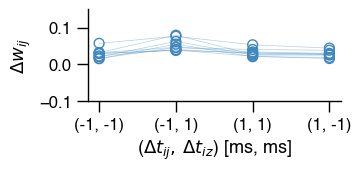

In [34]:
fig = test_time_lags(DATA_PATHS_NO_HET_SHORT_N5, a_pre=0.2, a_post=0.2, z=1, w_ij=0, ylim=(-0.1, 0.15))
fig.savefig(f'./figures/learning_rules/n5_no_het_triplet_time_lags_w_0.svg')

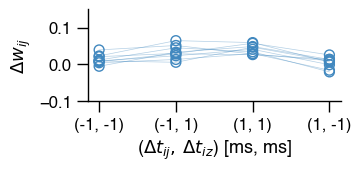

In [35]:
fig = test_time_lags(DATA_PATHS_NO_HET_SHORT_N5, a_pre=0.2, a_post=0.2, z=1, w_ij=1.5, ylim=(-0.1, 0.15))
fig.savefig(f'./figures/learning_rules/n5_no_het_triplet_time_lags_w_1p5.svg')

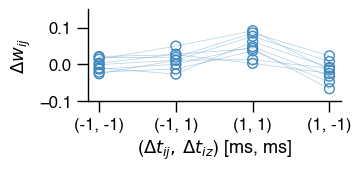

In [36]:
fig = test_time_lags(DATA_PATHS_NO_HET_SHORT_N5, a_pre=0.2, a_post=0.2, z=1, w_ij=3, ylim=(-0.1, 0.15))
fig.savefig(f'./figures/learning_rules/n5_no_het_triplet_time_lags_w_3.svg')

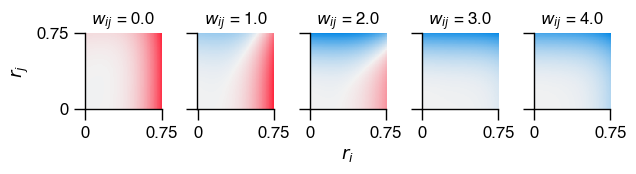

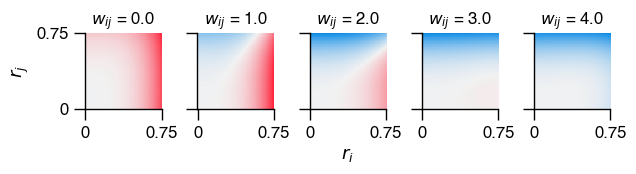

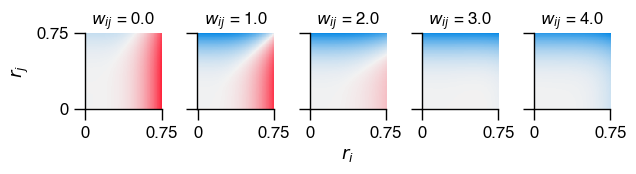

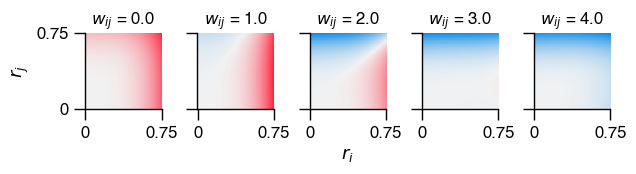

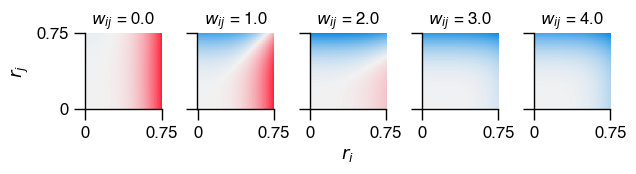

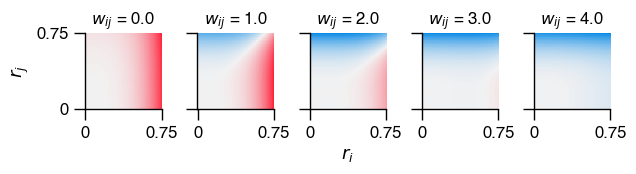

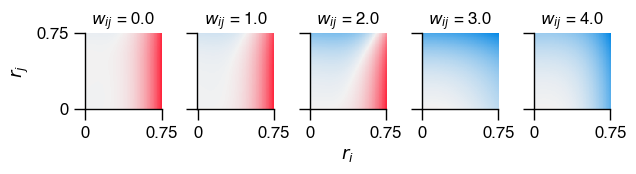

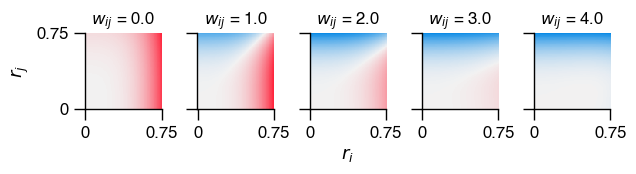

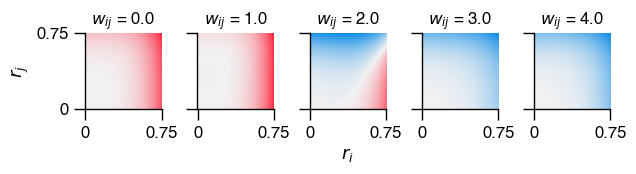

In [224]:
for i, df in enumerate(DATA_PATHS_NO_HET_SHORT_N5):
    coefs = load_coefs(df)
    w = np.linspace(0, 4, 5)
    a_pre = np.linspace(0, 0.75, 100)
    a_post = np.linspace(0, 0.75, 100)
    fig, axs = compute_weight_change_for_steady_state_firing(coefs, a_pre, a_post, w)
    fig.savefig(f'./figures/learning_rules/n5_no_het_short_steady_rates_{i}.svg')

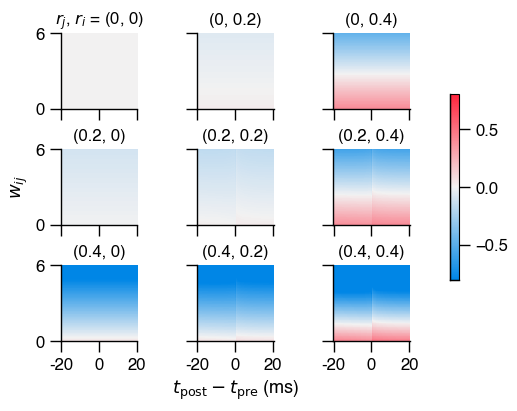

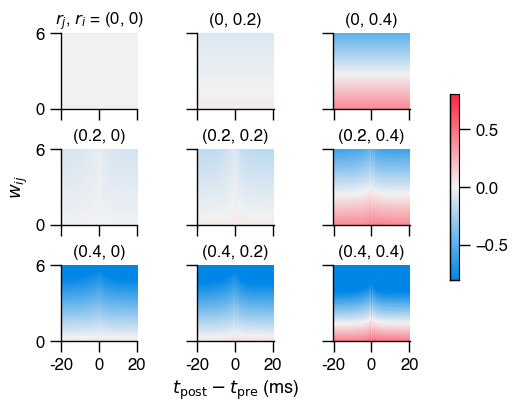

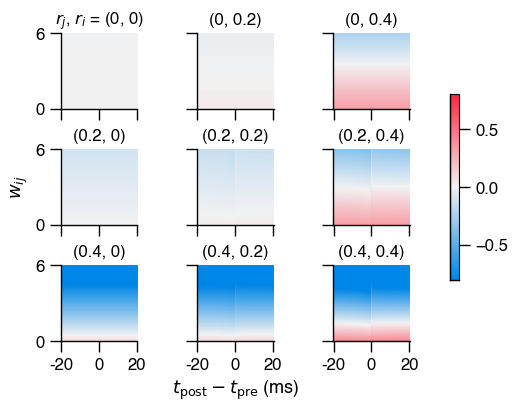

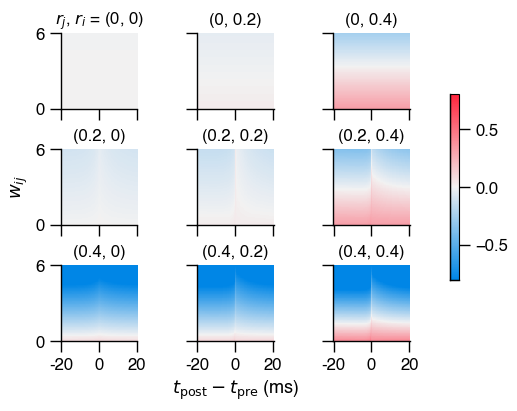

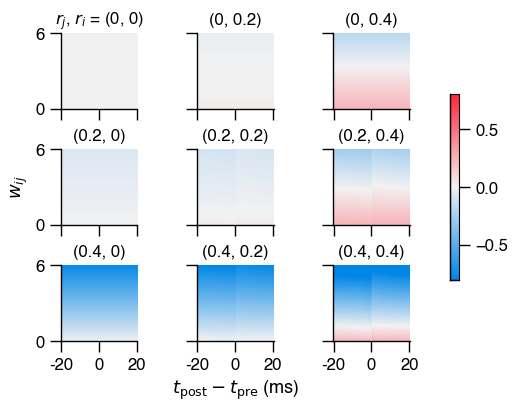

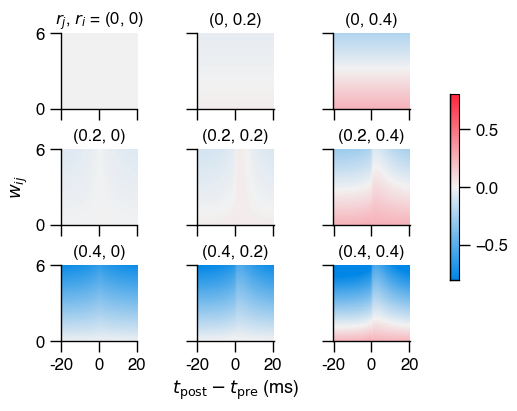

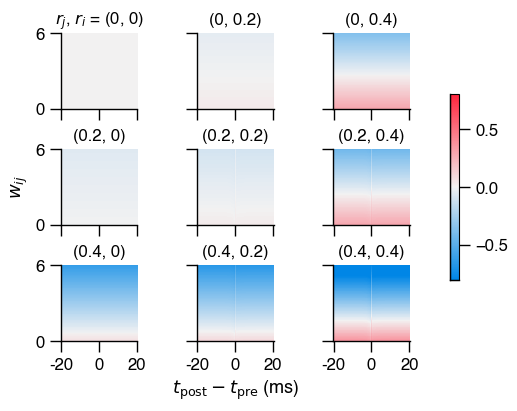

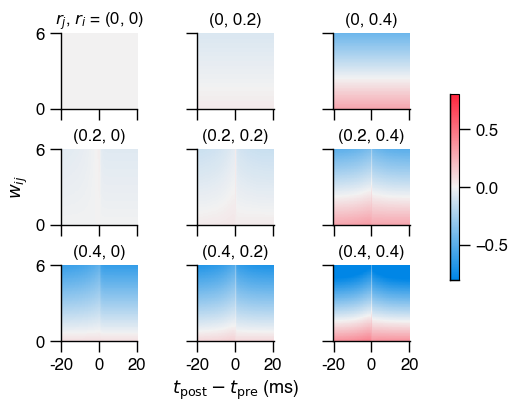

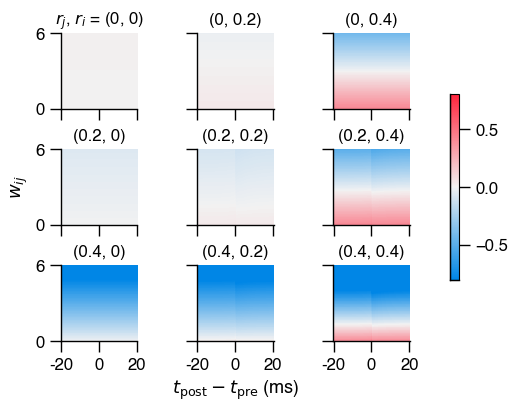

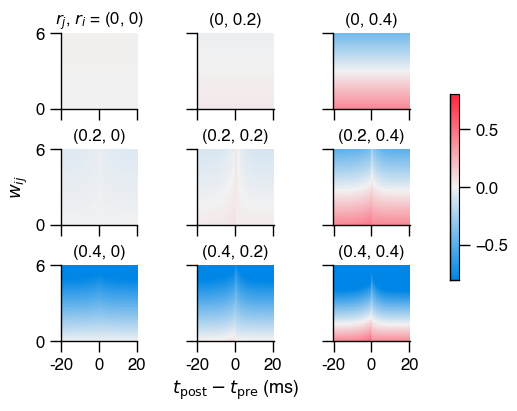

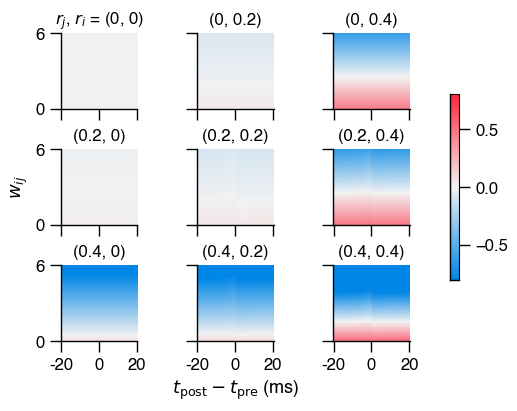

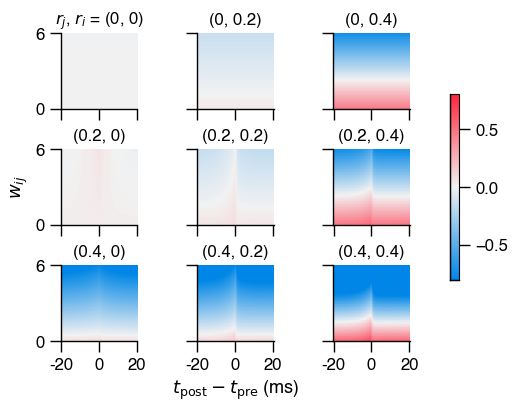

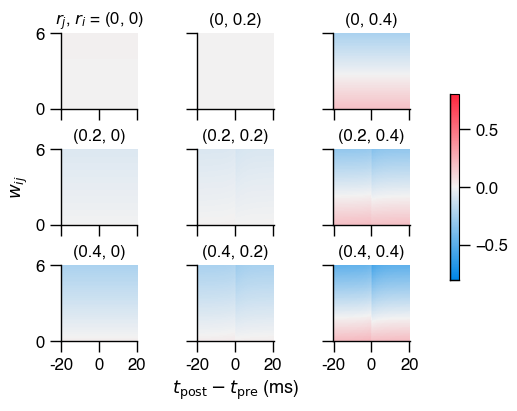

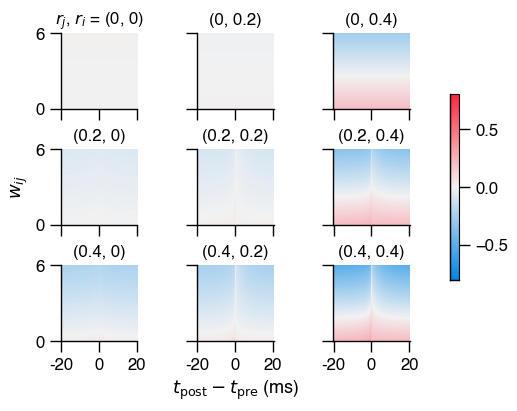

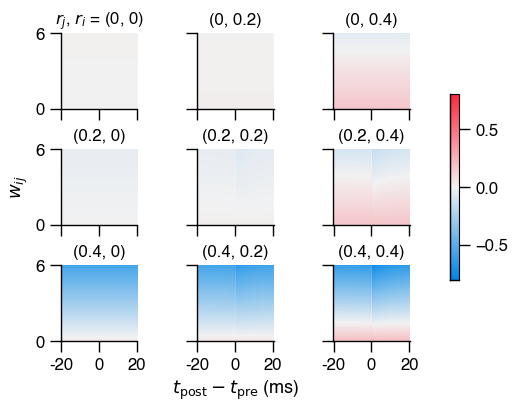

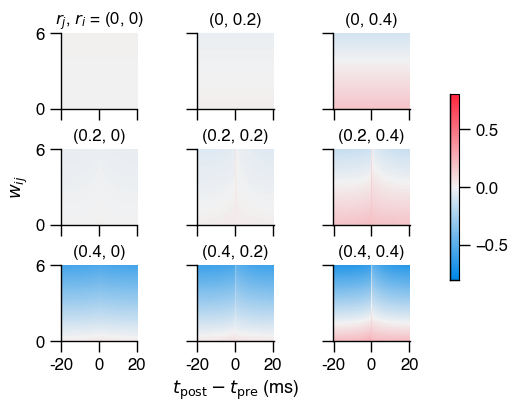

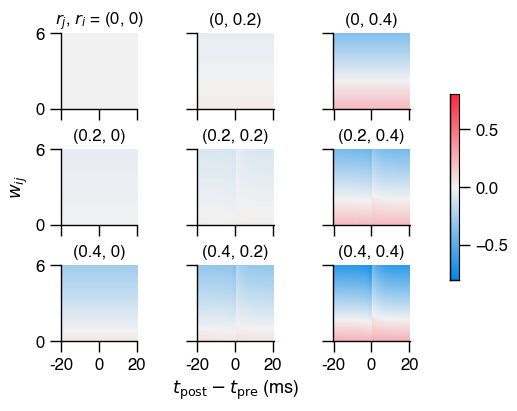

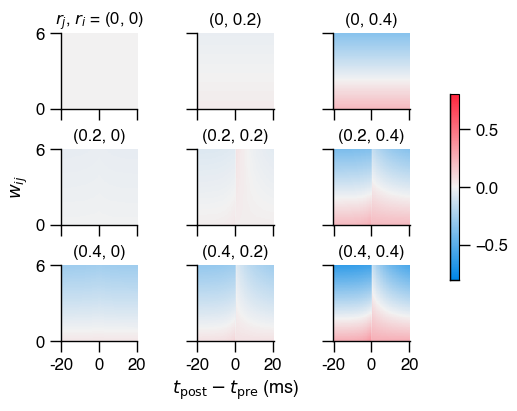

In [252]:
for i, df in enumerate(DATA_PATHS_NO_HET_SHORT_N5):
    coefs = load_coefs(df)
    fig, axs = plot_rules_under_input(coefs, z=0, t_lag_post_z=0, v=0.8)
    fig.savefig(f'./figures/learning_rules/n5_no_het_short_full_{i}_z_0.svg')
    fig, axs = plot_rules_under_input(coefs, z=0.5, t_lag_post_z=0, v=0.8)
    fig.savefig(f'./figures/learning_rules/n5_no_het_short_full_{i}_z_0p5.svg')

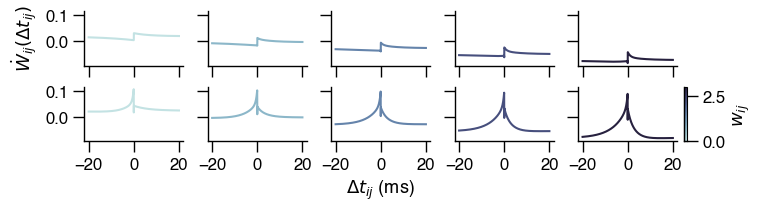

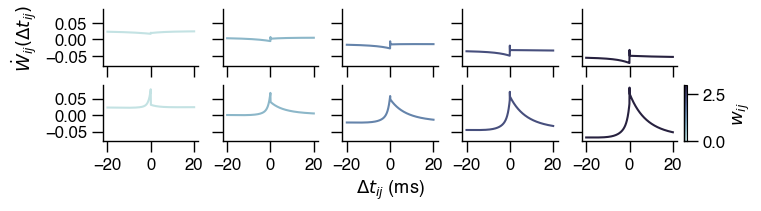

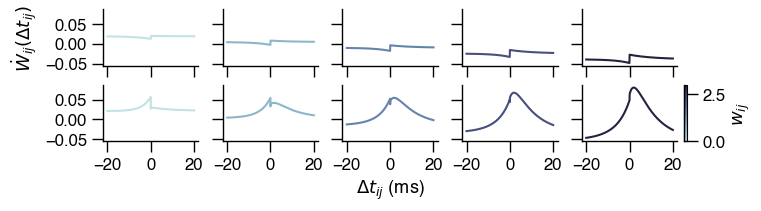

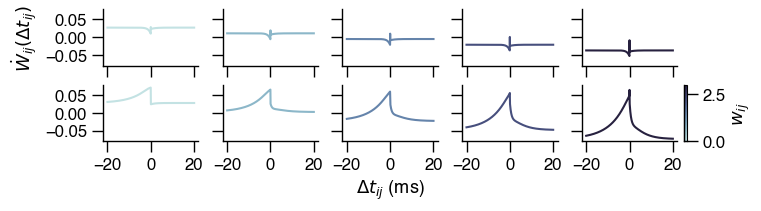

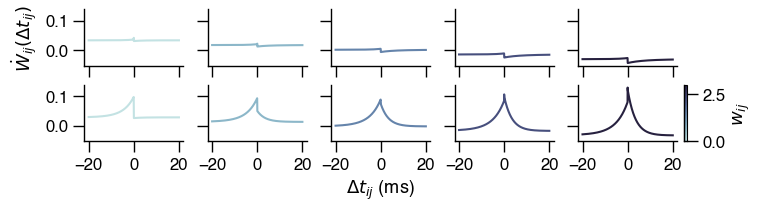

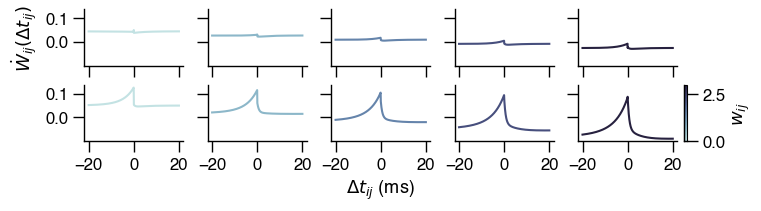

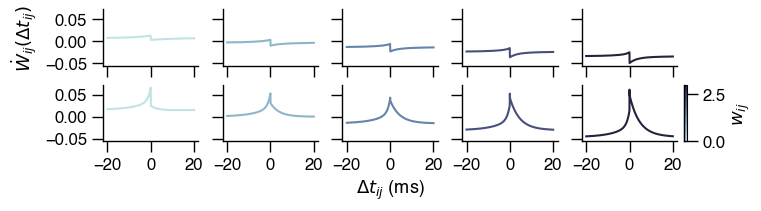

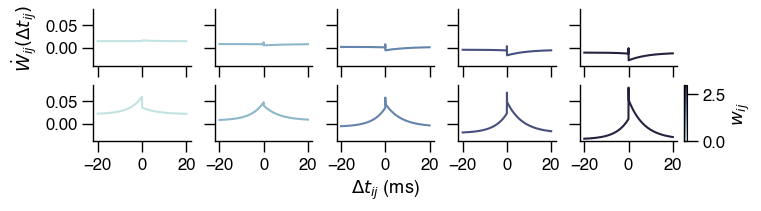

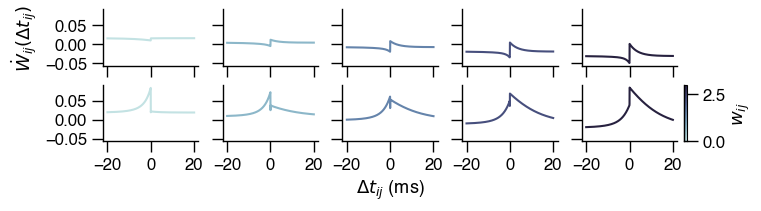

In [24]:
plot_kernels_across_weight(DATA_PATHS_NO_HET_SHORT_N5, zs=[0, 1], save_path='./figures/learning_rules/n5_no_het_short')

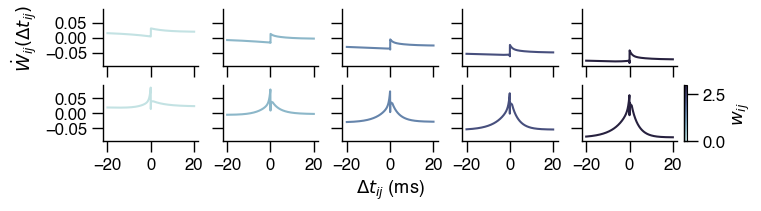

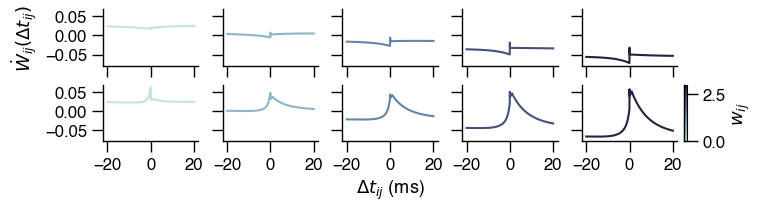

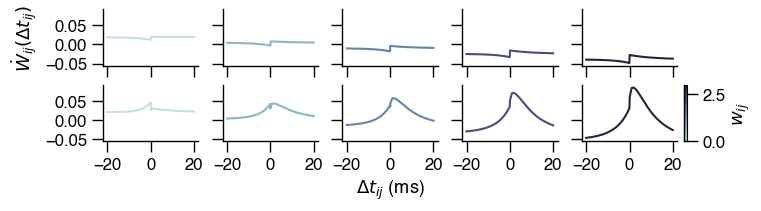

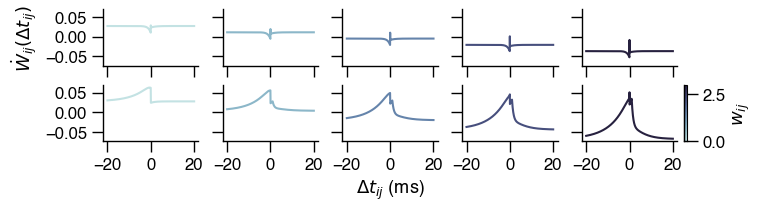

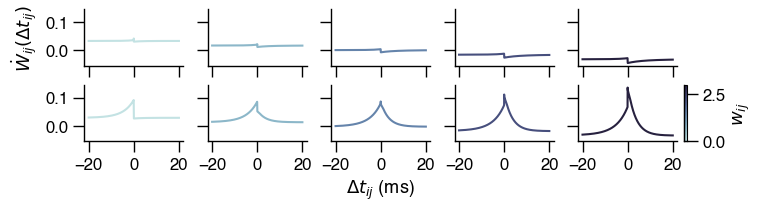

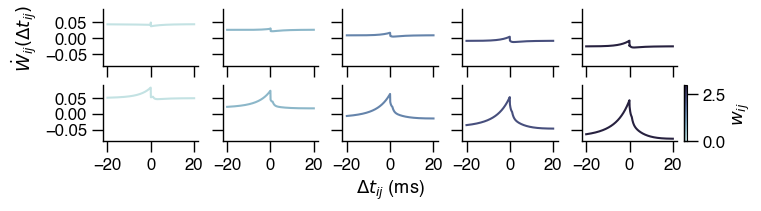

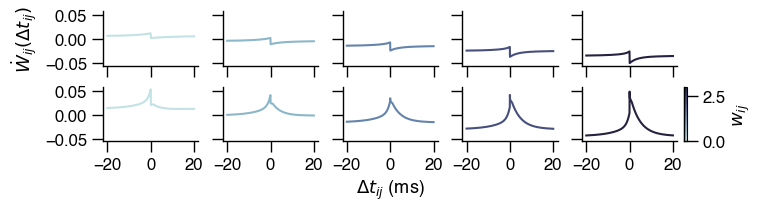

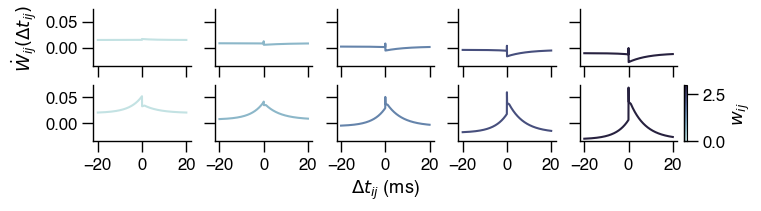

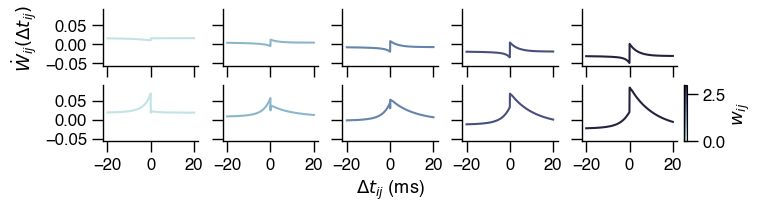

In [25]:
plot_kernels_across_weight(DATA_PATHS_NO_HET_SHORT_N5, zs=[0, 1], t_lag_post_z=1e-3, save_path='./figures/learning_rules/n5_no_het_short')

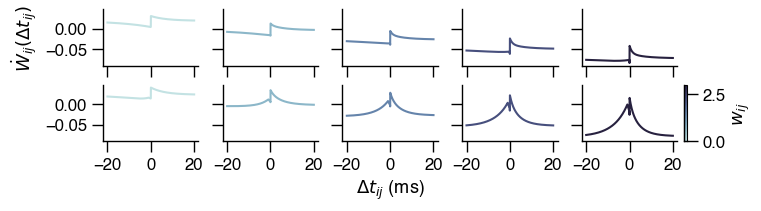

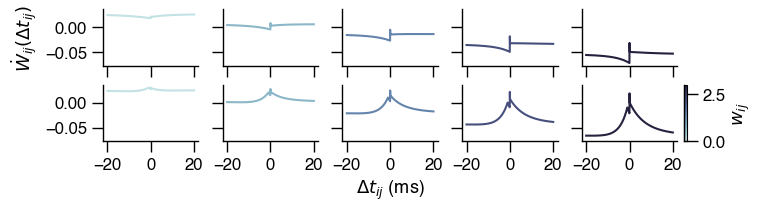

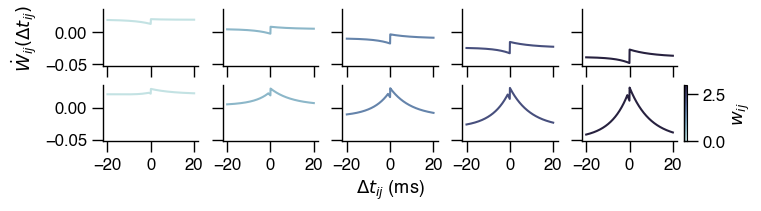

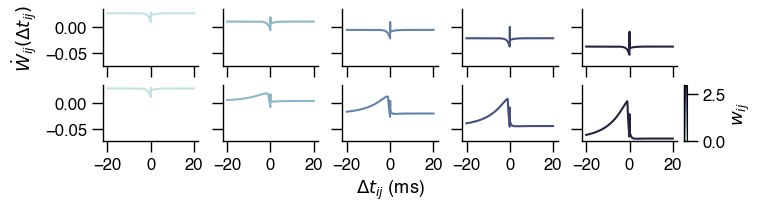

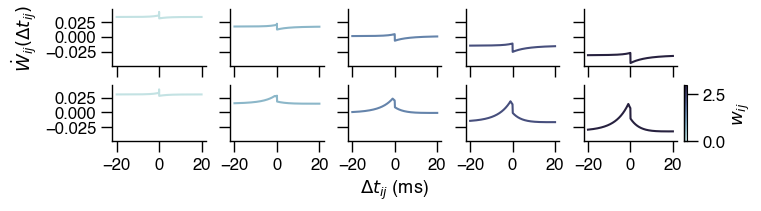

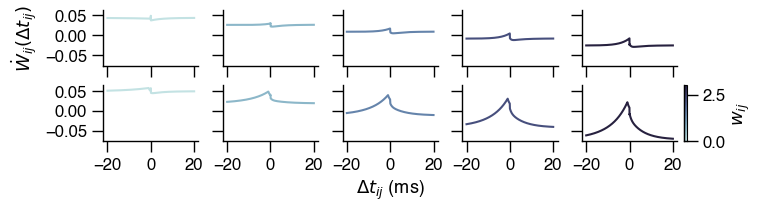

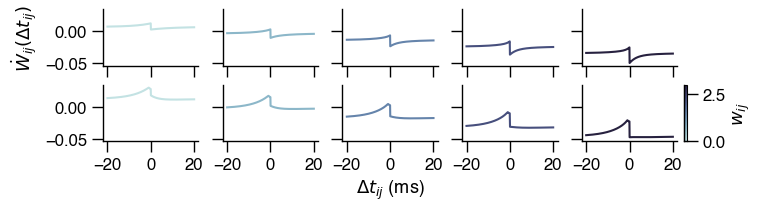

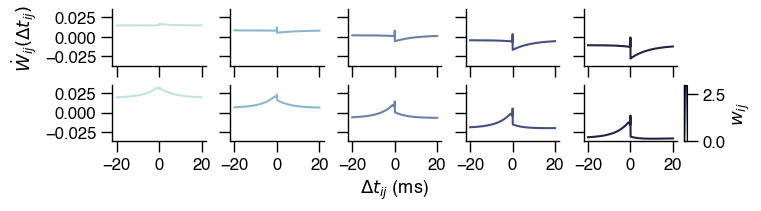

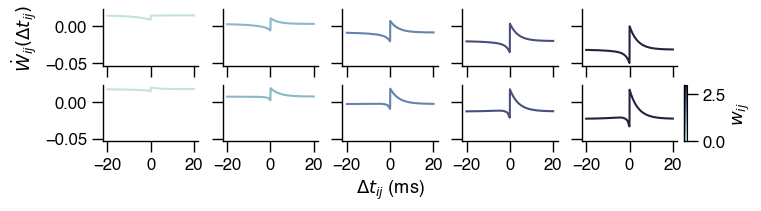

In [26]:
plot_kernels_across_weight(DATA_PATHS_NO_HET_SHORT_N5, zs=[0, 1], t_lag_post_z=-1e-3, save_path='./figures/learning_rules/n5_no_het_short')

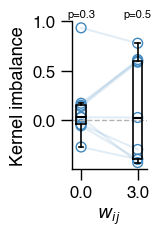

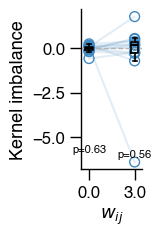

In [75]:
fig, axs = plot_all_kernels_across_w(DATA_PATHS_NO_HET_SHORT_N5, w_ij=np.linspace(0, 3, 10), t_lags=[30e-3], z=0, ylim=None, jitter=0, a_pre=0.2, a_post=0.2)
fig.savefig(f'./figures/learning_rules/n5_no_het_short_kernel_asym_w_0.svg')

fig, axs = plot_all_kernels_across_w(DATA_PATHS_NO_HET_LONG_N5, w_ij=np.linspace(0, 3, 10), t_lags=[30e-3], z=0, ylim=None, jitter=0, a_pre=0.2, a_post=0.2)


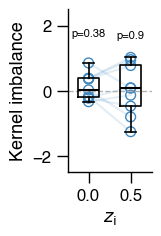

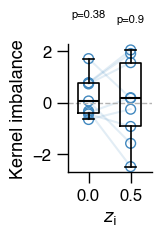

In [51]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_SHORT_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=1.5, ylim=(-2.5, 2.5), jitter=0)
fig.savefig(f'./figures/learning_rules/n5_no_het_short_kernel_asym_w_1p5.svg')

fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_SHORT_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=1.5, jitter=0, a_pre=0.4, a_post=0.2)


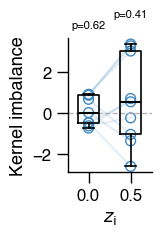

In [46]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_SHORT_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=5, jitter=0)
fig.savefig(f'./figures/learning_rules/n5_no_het_short_kernel_asym_w_3.svg')

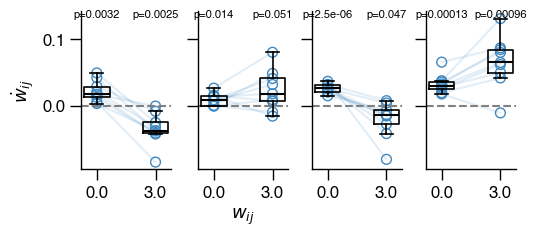

In [37]:
# Across weight, plot weight change for pre-post pairing, pre-z pairing, post-z pairing
fig, axs = plot_coincident_activity_across_weight(DATA_PATHS_NO_HET_SHORT_N5, np.linspace(0, 3, 10), a_pre=0.2, a_post=0.2, z=1)
fig.savefig(f'./figures/learning_rules/n5_no_het_short_pairwise_checks.svg')

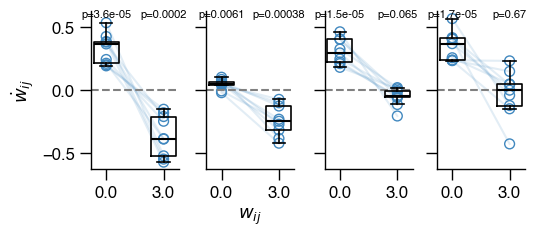

In [38]:
# Across weight, plot weight change for pre-post pairing, pre-z pairing, post-z pairing
fig, axs = plot_coincident_activity_across_weight(DATA_PATHS_NO_HET_SHORT_N5, np.linspace(0, 3, 10), a_pre=0.4, a_post=0.4, z=1)
fig.savefig(f'./figures/learning_rules/n5_no_het_short_pairwise_checks.svg')

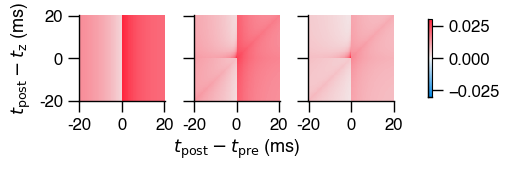

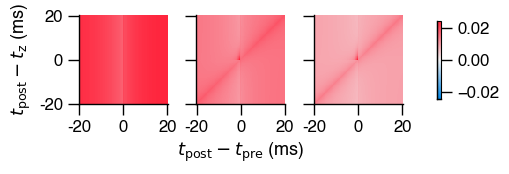

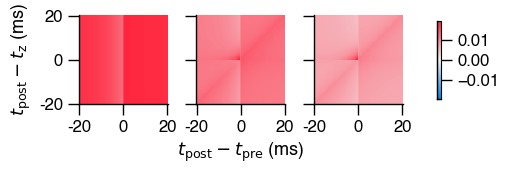

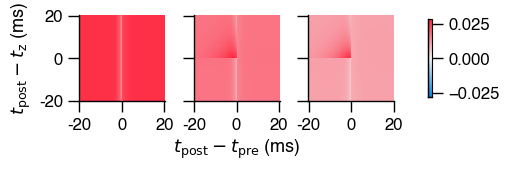

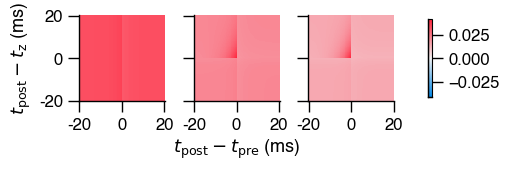

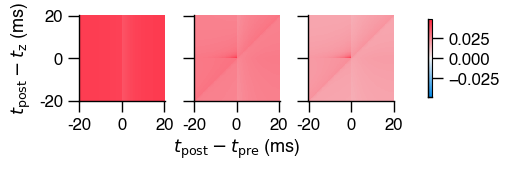

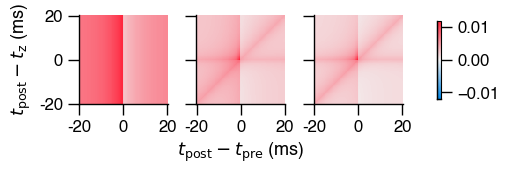

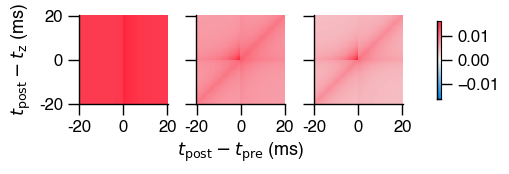

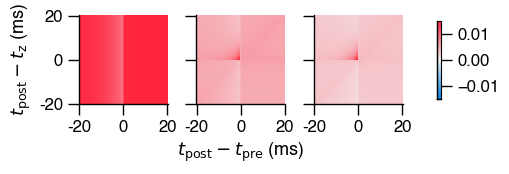

In [27]:
for i, df in enumerate(DATA_PATHS_NO_HET_SHORT_N5):
    coefs = load_coefs(df)
    fig, axs = plot_rules_vary_z(coefs, w_ij=0)
    fig.savefig(f'./figures/learning_rules/n5_no_het_short_two_lags_rule_{i}_w_0.svg')

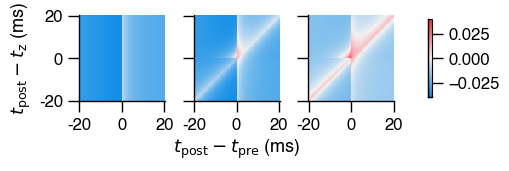

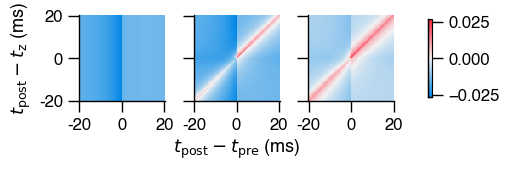

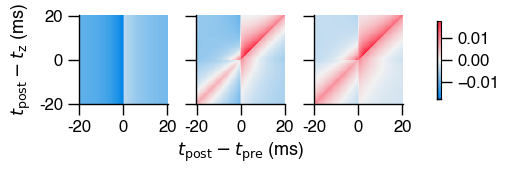

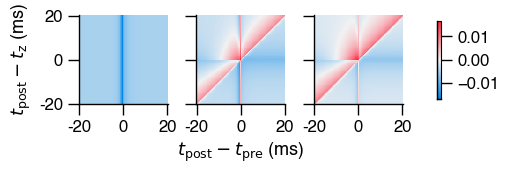

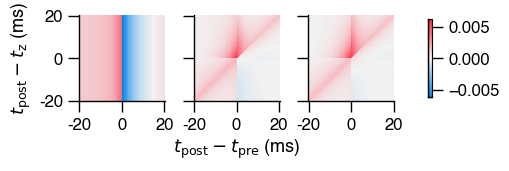

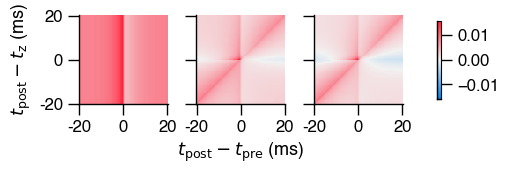

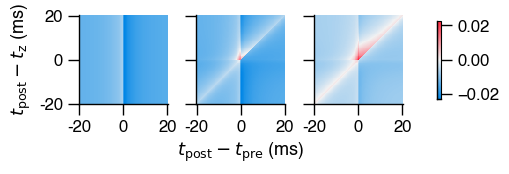

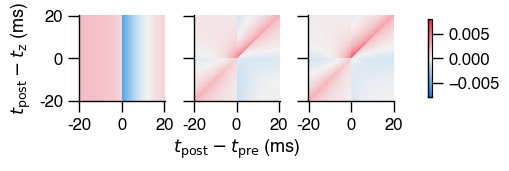

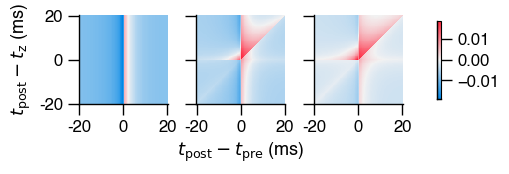

In [28]:
for i, df in enumerate(DATA_PATHS_NO_HET_SHORT_N5):
    coefs = load_coefs(df)
    fig, axs = plot_rules_vary_z(coefs, w_ij=1.5)
    fig.savefig(f'./figures/learning_rules/n5_no_het_short_two_lags_rule_{i}_w_1p5.svg')

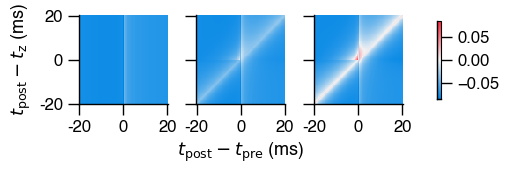

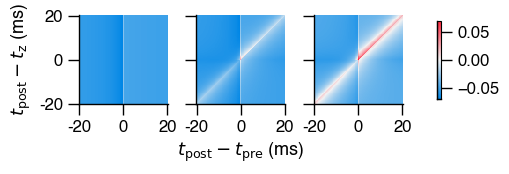

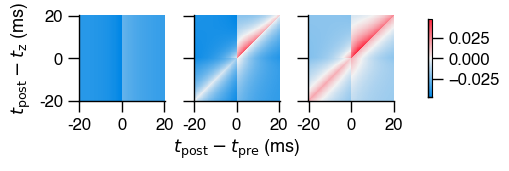

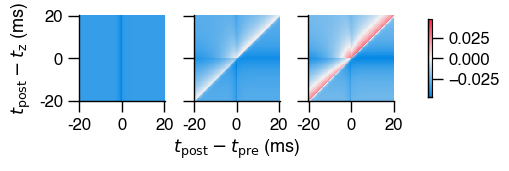

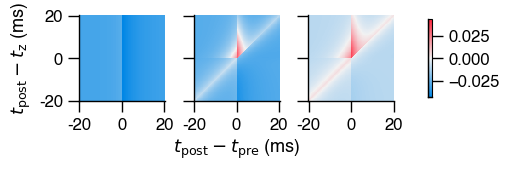

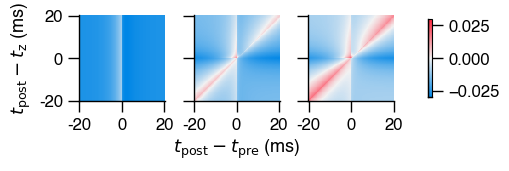

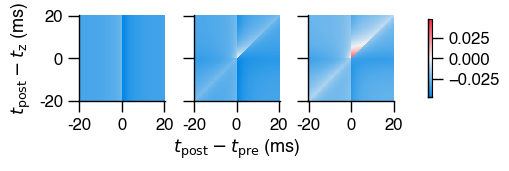

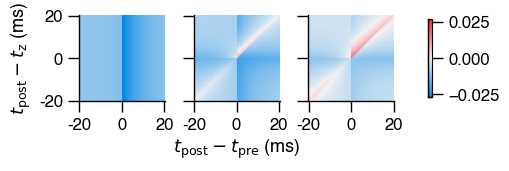

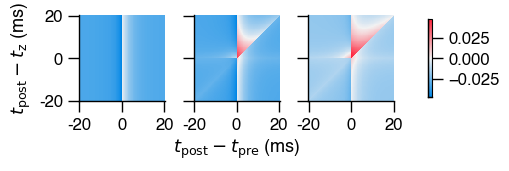

In [29]:
for i, df in enumerate(DATA_PATHS_NO_HET_SHORT_N5):
    coefs = load_coefs(df)
    fig, axs = plot_rules_vary_z(coefs, w_ij=3)
    fig.savefig(f'./figures/learning_rules/n5_no_het_short_two_lags_rule_{i}_w_3.svg')

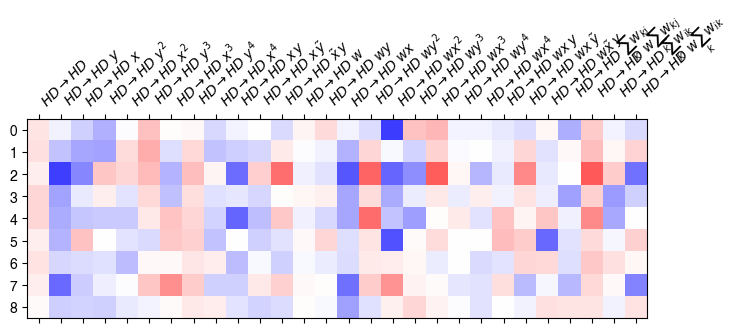

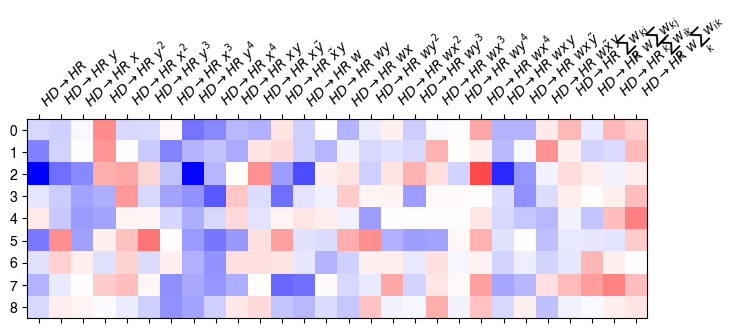

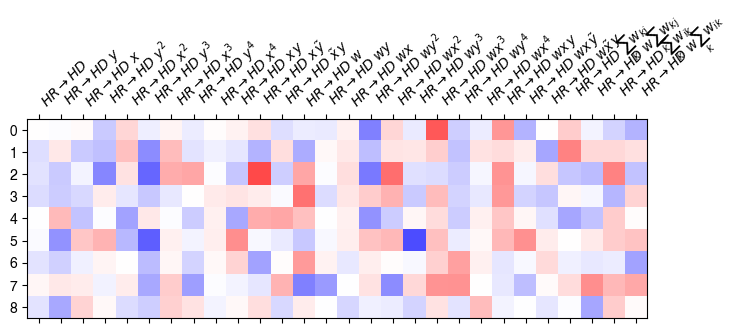

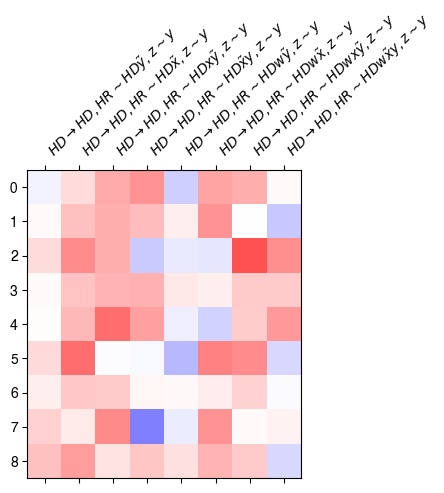

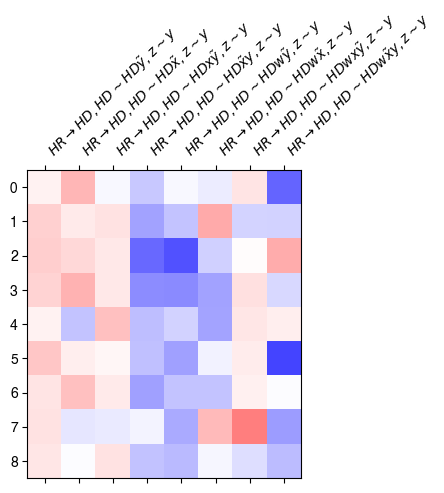

In [40]:
all_coefs = np.array([
    load_coefs(df)
    for df in DATA_PATHS_HET_SHORT_N5
])

m = np.abs(all_coefs[:, :N_RULES]).max()

stride = (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE)
for i in range(3):
    rules_for_proj_type = all_coefs[:, i * stride: (i+1) * stride]
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.matshow(rules_for_proj_type, vmax=m, vmin=-m, cmap='bwr')
    ax.set_xticks(np.arange(stride), rule_names[i * stride: (i+1) * stride], rotation=45, ha='left')
    # format_plot(ax)

m = np.abs(all_coefs[:, :N_RULES]).max()

start = 3 * (N_PAIRWISE_RULES_PER_TYPE + N_SUMMED_WEIGHT_RULES_PER_TYPE)
stride = N_THREE_FACTOR_RULES_PER_TYPE
for i in range(2):
    rules_for_proj_type = all_coefs[:, start + i * stride: start + (i+1) * stride]
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.matshow(rules_for_proj_type, vmax=m, vmin=-m, cmap='bwr')
    ax.set_xticks(np.arange(stride), rule_names[start + i * stride: start + (i+1) * stride], rotation=45, ha='left')
    # format_plot(ax)

(9, 4)


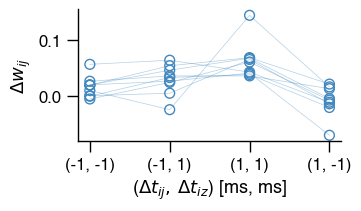

In [20]:
fig = test_time_lags(DATA_PATHS_HET_SHORT_N5, a_pre=0.2, a_post=0.2, z=1, w_ij=3)
fig.savefig(f'./figures/learning_rules/n5_het_triplet_time_lags.svg')

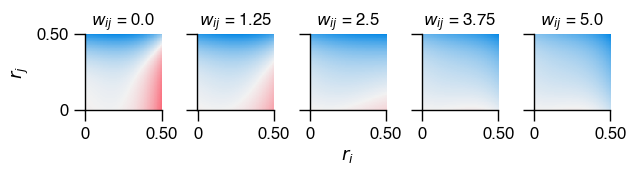

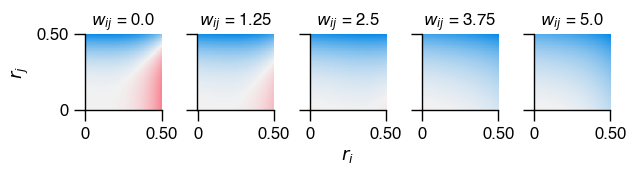

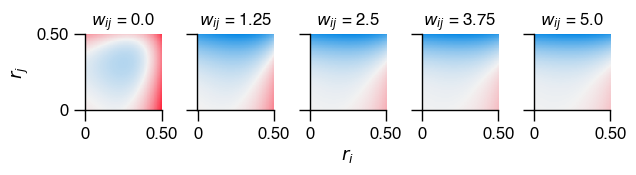

In [19]:
for df in DATA_PATHS_HET_SHORT_N5:
    coefs = load_coefs(df)
    w = np.linspace(0, 5, 5)
    a_pre = np.linspace(0, 0.5, 100)
    a_post = np.linspace(0, 0.5, 100)
    compute_weight_change_for_steady_state_firing(coefs, a_pre, a_post, w)

In [ ]:
for df in DATA_PATHS_HET_SHORT_N5:
    coefs = load_coefs(df)
    plot_rules_under_input(coefs, z=0, t_lag_post_z=0, v=0.3)
    plot_rules_under_input(coefs, z=0.5, t_lag_post_z=0, v=0.3)

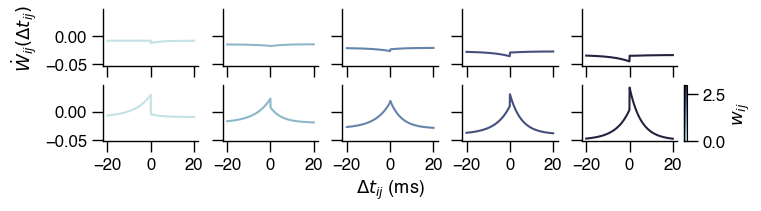

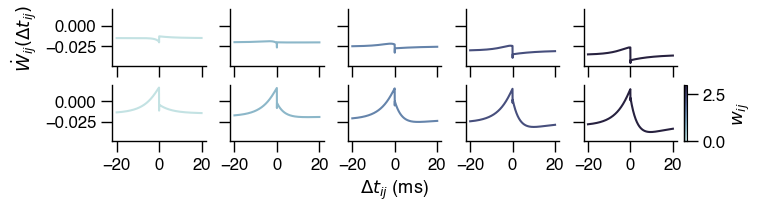

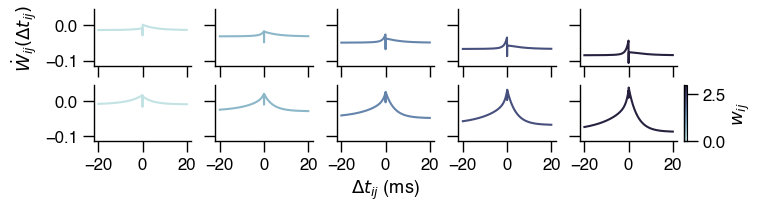

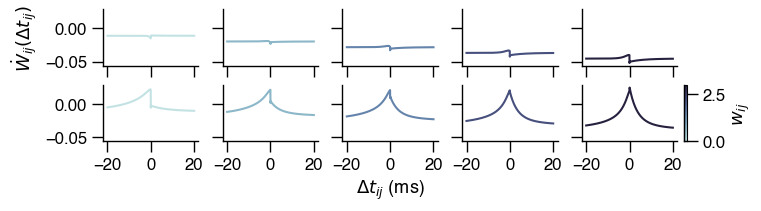

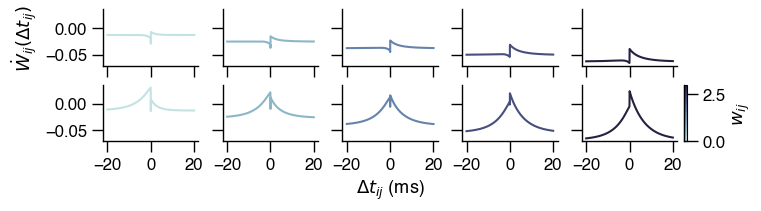

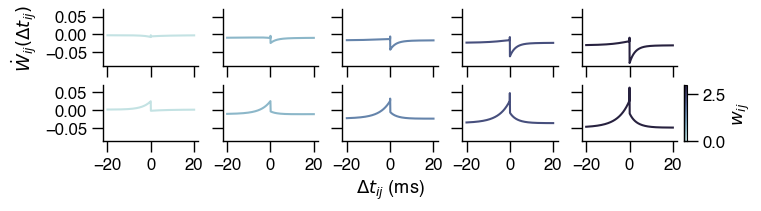

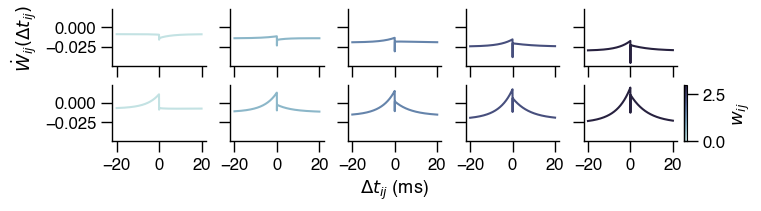

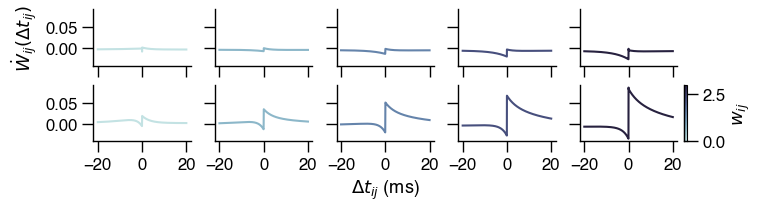

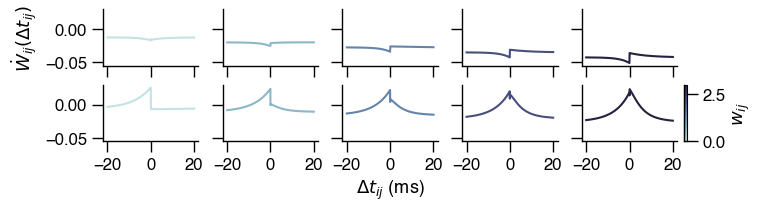

In [20]:
plot_kernels_across_weight(DATA_PATHS_HET_SHORT_N5, zs=[0, 0.5])

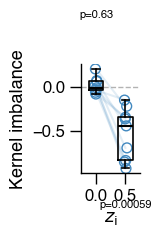

In [87]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_HET_SHORT_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=0, jitter=0.01)
fig.savefig(f'./figures/learning_rules/n5_het_short_kernel_asym_w_0.svg')

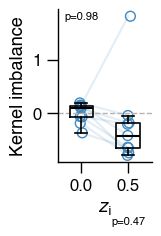

In [85]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_HET_SHORT_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=1.5, jitter=0.01)
fig.savefig(f'./figures/learning_rules/n5_het_short_kernel_asym_w_1p5.svg')

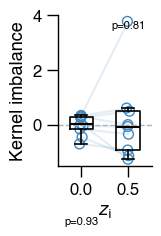

In [86]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_HET_SHORT_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=3, jitter=0.01)
fig.savefig(f'./figures/learning_rules/n5_no_het_short_kernel_asym_w_3.svg')

(<Figure size 525x225 with 4 Axes>,
 array([<Axes: ylabel='$\\dot{w}_{ij}$'>, <Axes: xlabel='$w_{ij}$'>,
        <Axes: >, <Axes: >], dtype=object))

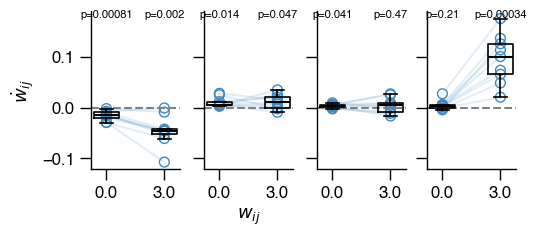

In [19]:
plot_coincident_activity_across_weight(DATA_PATHS_HET_SHORT_N5, np.linspace(0, 3, 10), a_pre=0.2, a_post=0.2, z=1)

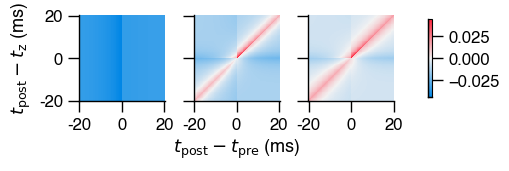

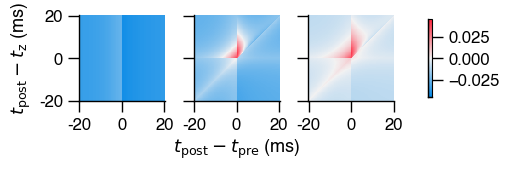

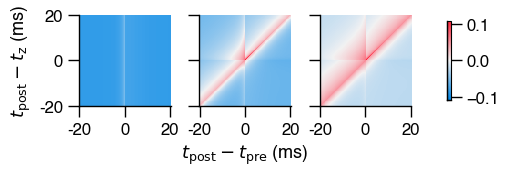

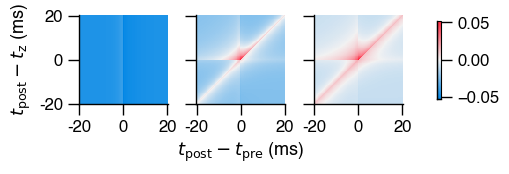

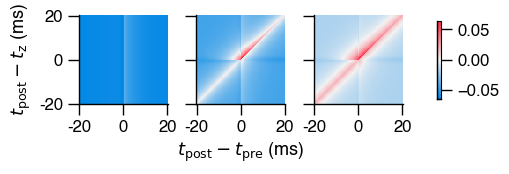

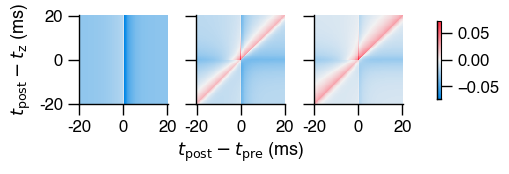

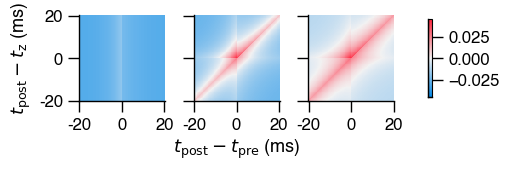

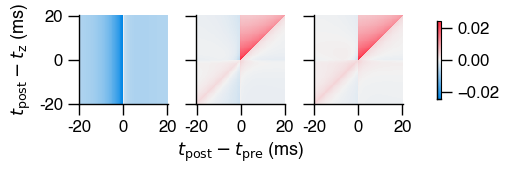

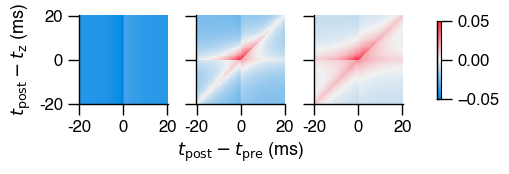

In [44]:
for df in DATA_PATHS_HET_SHORT_N5:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=3, z_max=2, a_pre=0.2, a_post=0.2)

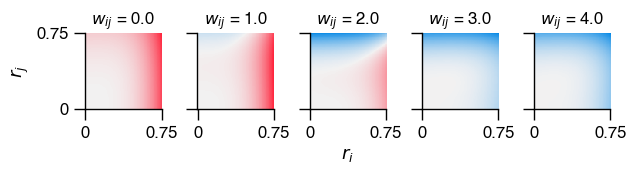

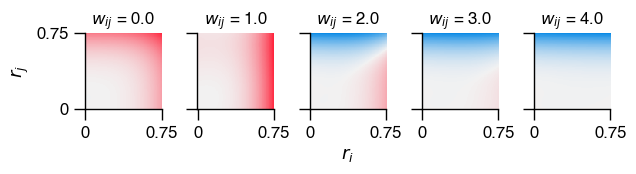

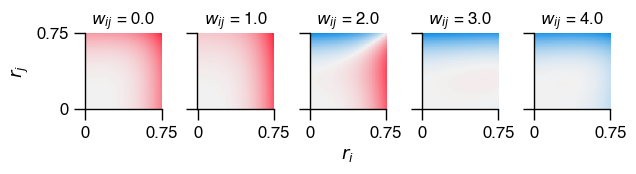

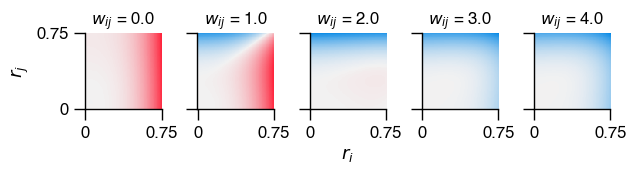

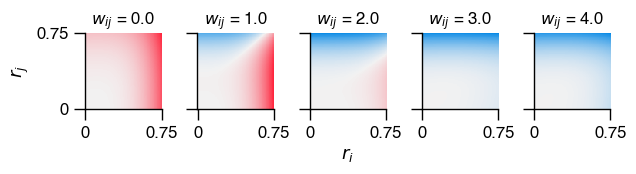

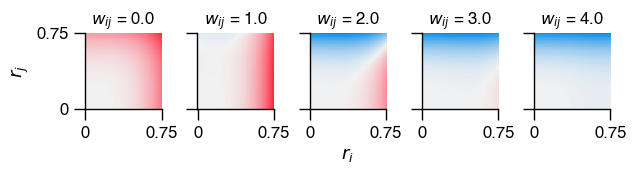

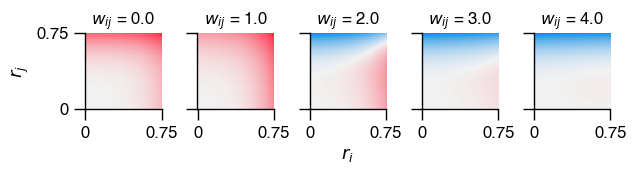

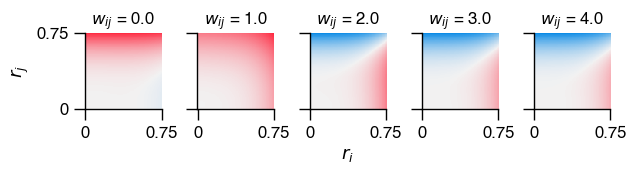

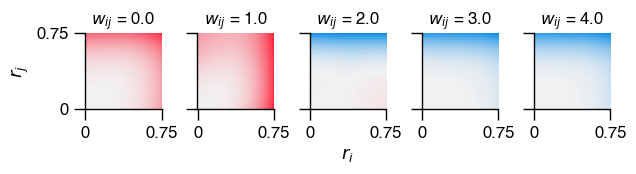

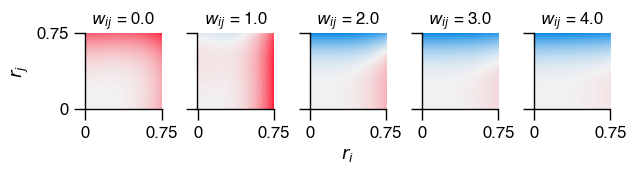

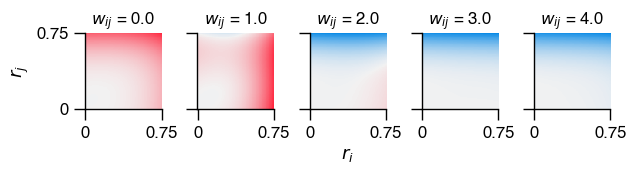

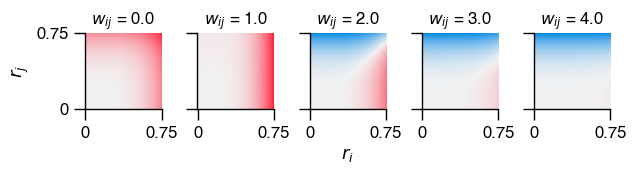

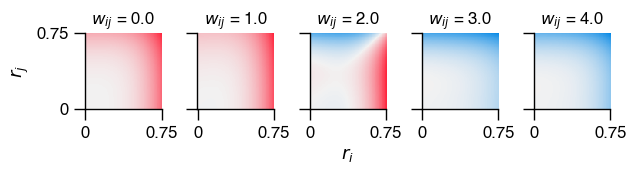

In [43]:
for i, df in enumerate(DATA_PATHS_NO_HET_LONG_N5):
    coefs = load_coefs(df)
    w = np.linspace(0, 4, 5)
    a_pre = np.linspace(0, 0.75, 100)
    a_post = np.linspace(0, 0.75, 100)
    fig, axs = compute_weight_change_for_steady_state_firing(coefs, a_pre, a_post, w)
    fig.savefig(f'./figures/learning_rules/n5_no_het_long_steady_rates_{i}.svg')

/tmp/ipykernel_3382437/785359680.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(3, 3, sharex=True, sharey=True, constrained_layout=True, figsize=(5, 4))


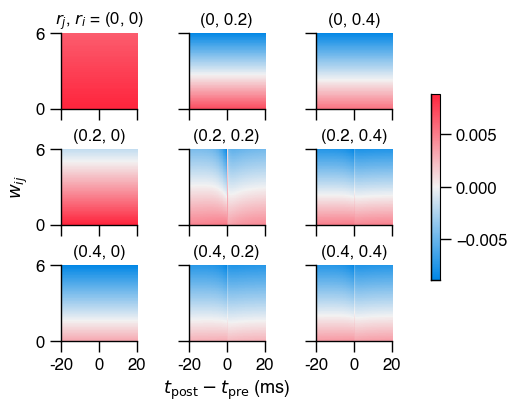

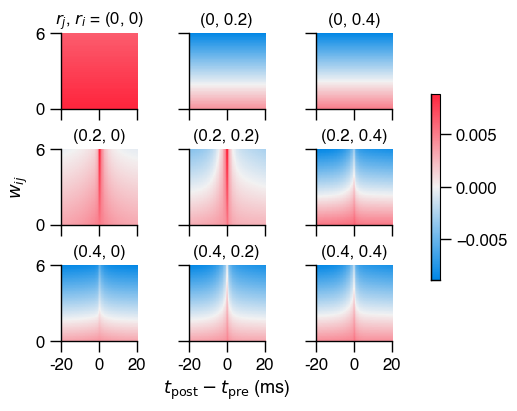

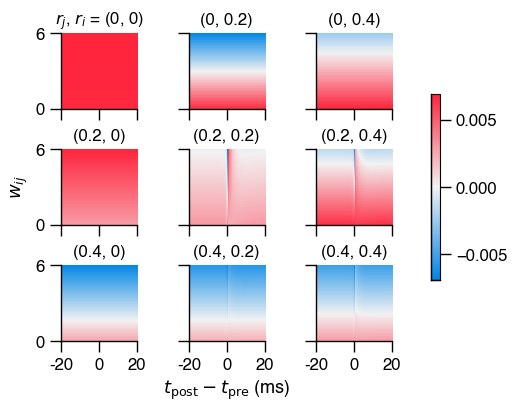

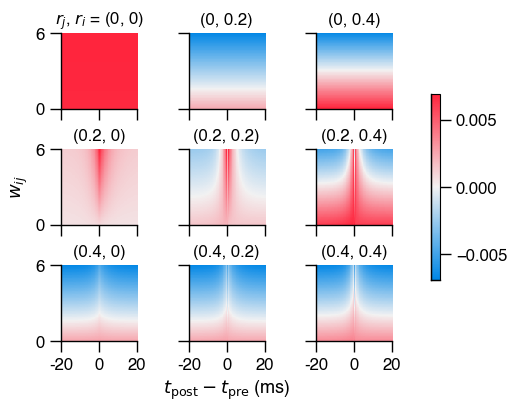

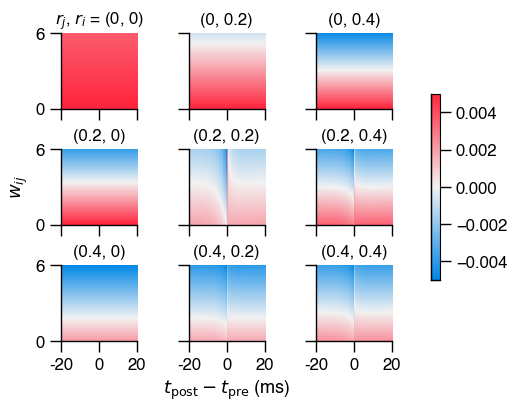

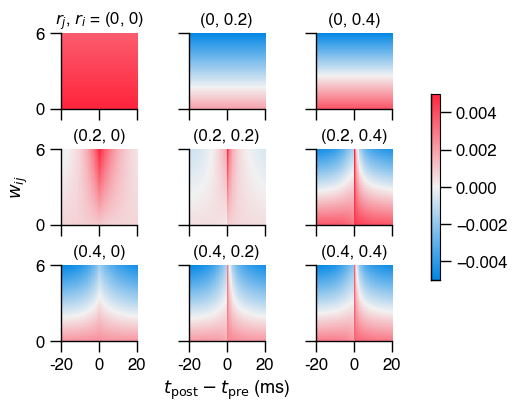

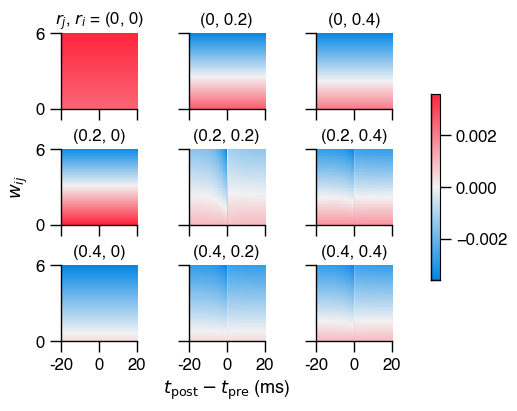

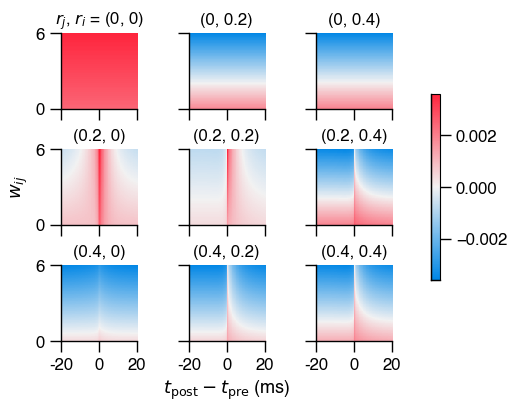

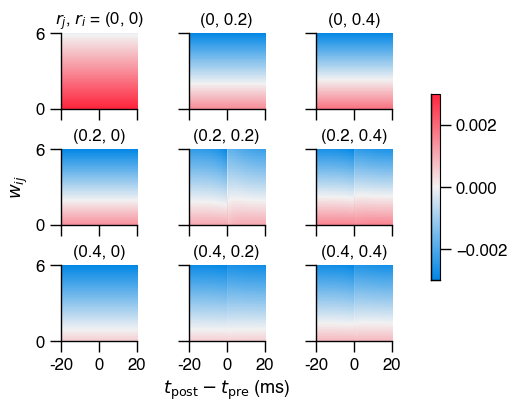

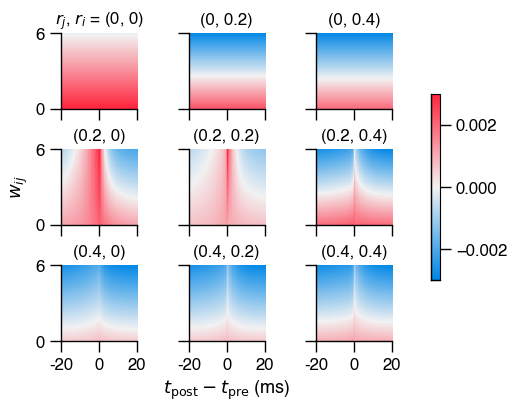

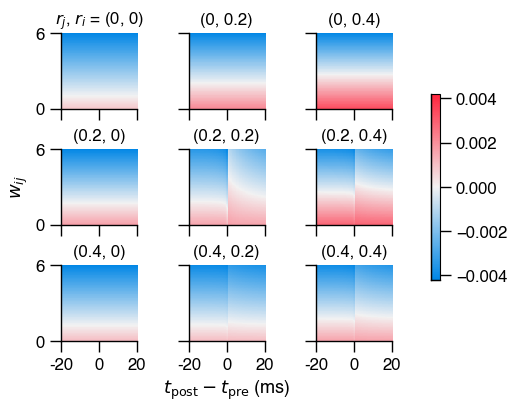

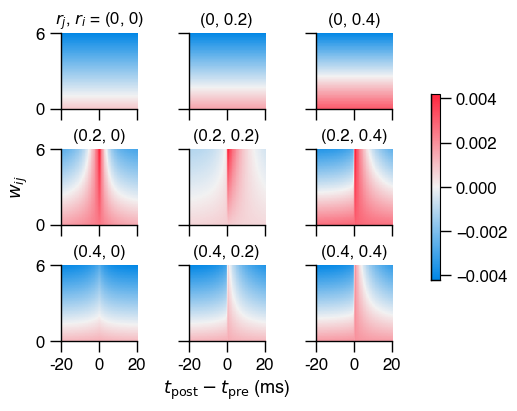

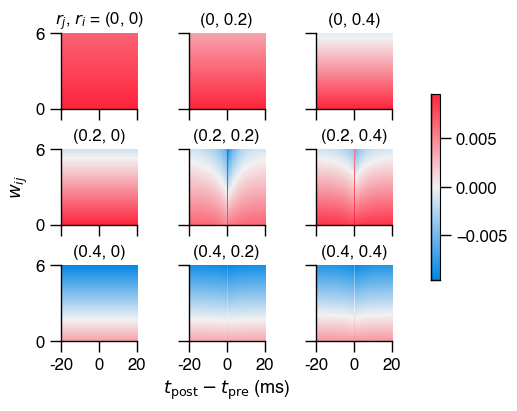

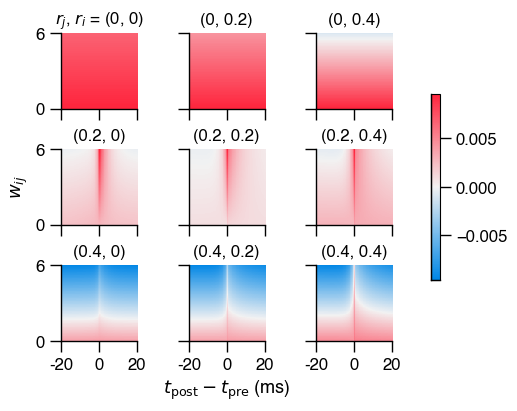

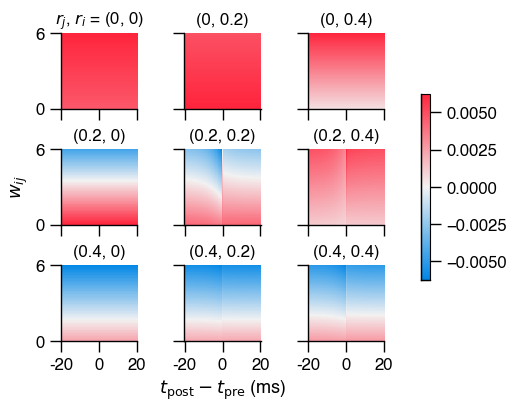

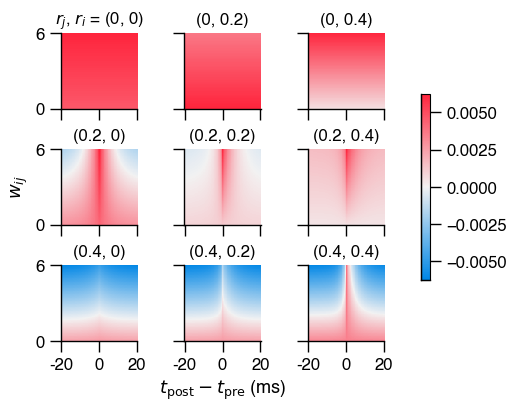

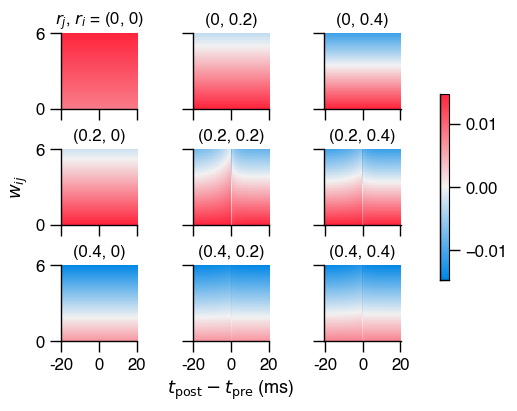

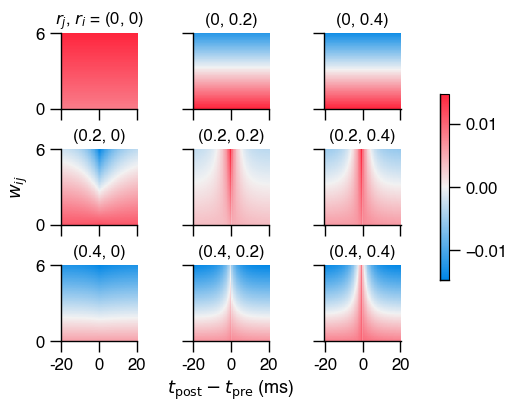

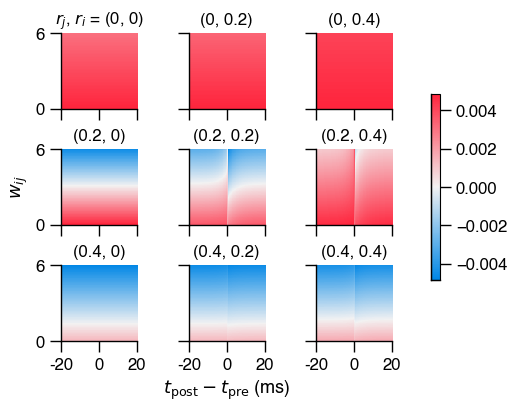

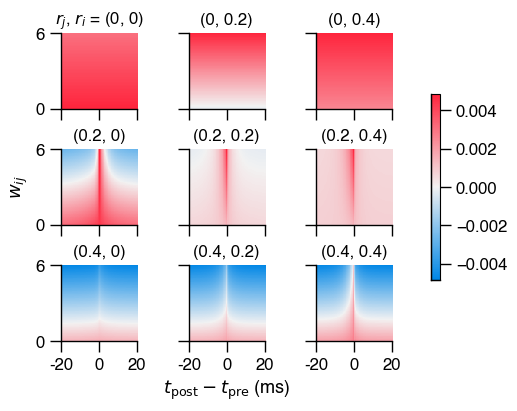

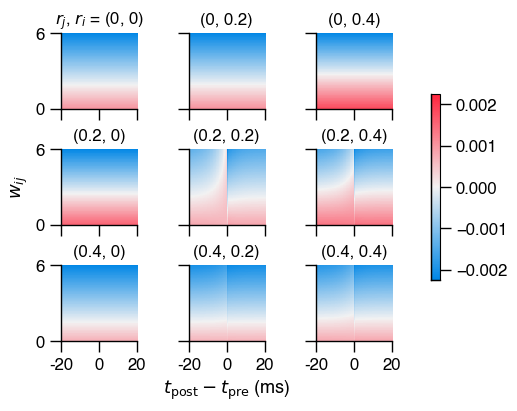

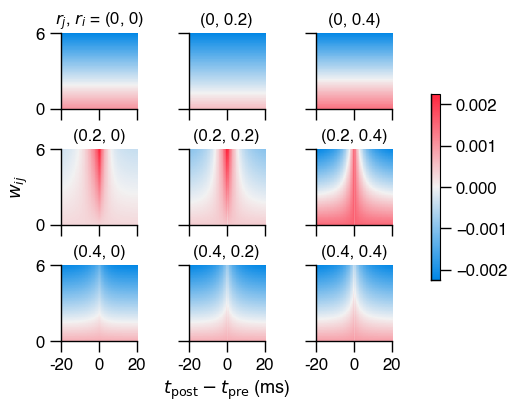

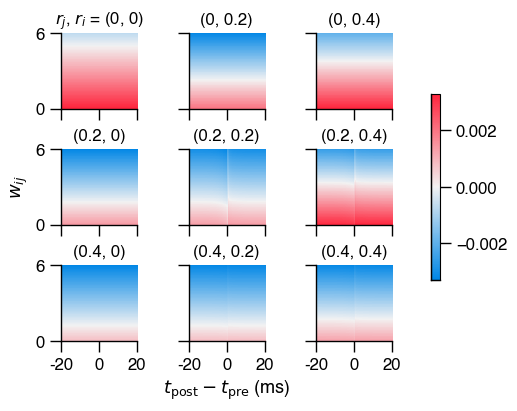

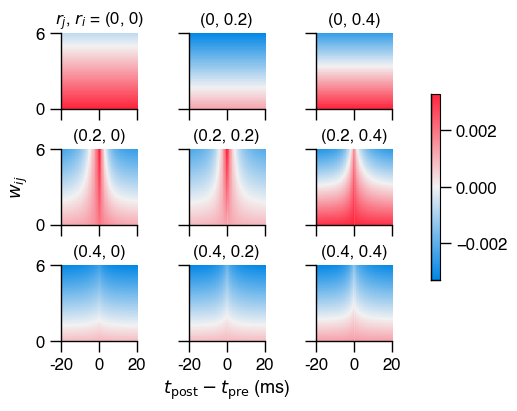

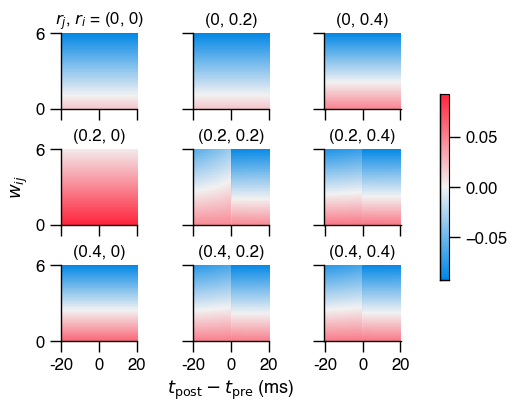

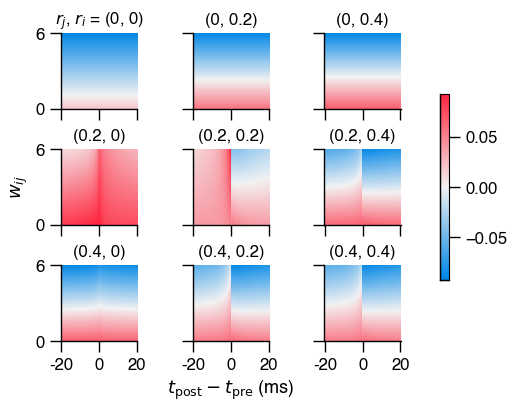

In [75]:
for df in DATA_PATHS_NO_HET_LONG_N5:
    coefs = load_coefs(df)
    plot_rules_under_input(coefs, z=0, t_lag_post_z=0) #v=0.5)
    plot_rules_under_input(coefs, z=0.5, t_lag_post_z=0) #v=0.5)

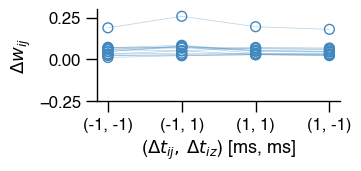

In [42]:
fig = test_time_lags(DATA_PATHS_NO_HET_LONG_N5, a_pre=0.2, a_post=0.2, z=0.5, w_ij=0, ylim=(-0.25, 0.3))

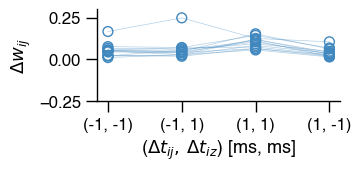

In [43]:
fig = test_time_lags(DATA_PATHS_NO_HET_LONG_N5, a_pre=0.2, a_post=0.2, z=0.5, w_ij=1.5, ylim=(-0.25, 0.3))

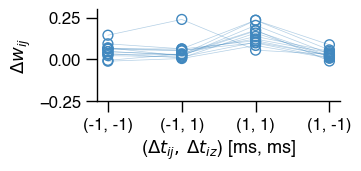

In [41]:
fig = test_time_lags(DATA_PATHS_NO_HET_LONG_N5, a_pre=0.2, a_post=0.2, z=0.5, w_ij=3, ylim=(-0.25, 0.3))

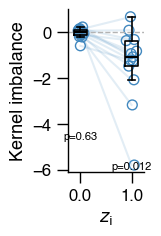

In [33]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_LONG_N5, z=np.linspace(0, 1, 10), t_lags=[30e-3], w_ij=0, jitter=0.05)
fig.savefig(f'./figures/learning_rules/n5_no_het_long_kernel_asym_w_0.svg')

/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/numpy/_core/_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1214: RuntimeWarning: invalid value encountered in scalar multiply
  var *= np.divide(n, n-ddof)  # to avoid error on division by zero
/mmfs1/gscratch/labfairhall/davidgbe

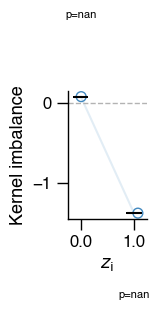

In [57]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_LONG_N5[3:4], z=np.linspace(0, 1, 10), t_lags=[30e-3], w_ij=0.75, jitter=0.05)
fig.savefig(f'./figures/learning_rules/n5_no_het_long_kernel_asym_w_0.svg')

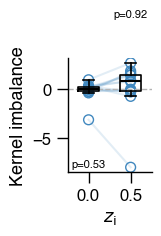

In [53]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_LONG_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=1.5)
fig.savefig(f'./figures/learning_rules/n5_no_het_long_kernel_asym_w_1p5.svg')

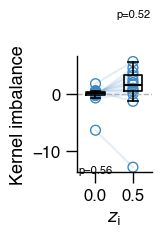

In [54]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_LONG_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=3)
fig.savefig(f'./figures/learning_rules/n5_no_het_long_kernel_asym_w_3.svg')

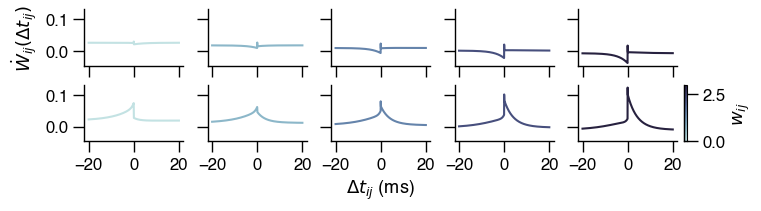

In [58]:
plot_kernels_across_weight(DATA_PATHS_NO_HET_LONG_N5[3:4], zs=[0, 0.5], t_lag_post_z=0)

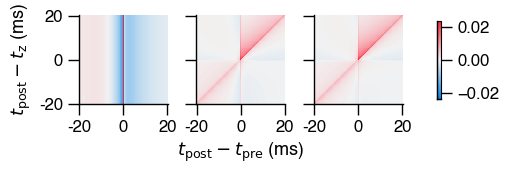

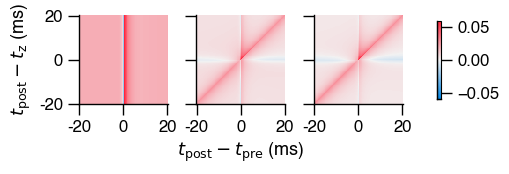

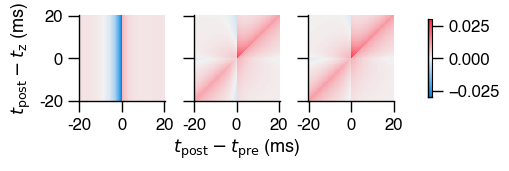

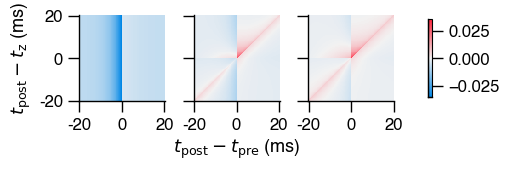

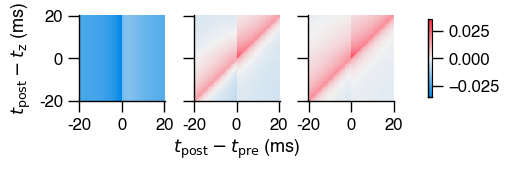

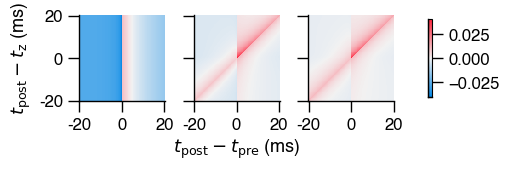

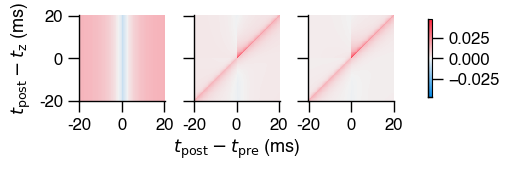

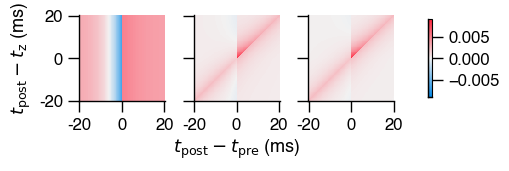

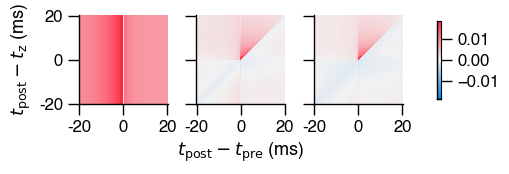

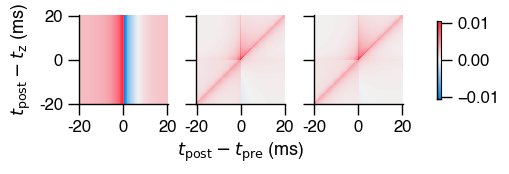

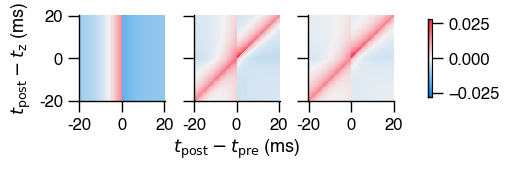

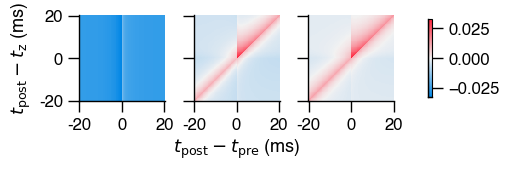

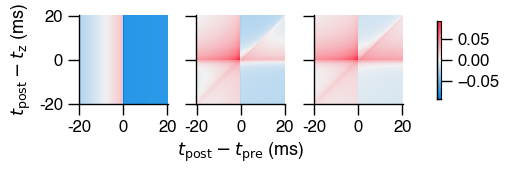

In [20]:
for df in DATA_PATHS_NO_HET_LONG_N5:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=3, scale=1, a_pre=0.2, a_post=0.2, z_max=1, z_min=0)

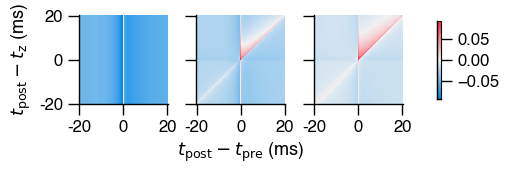

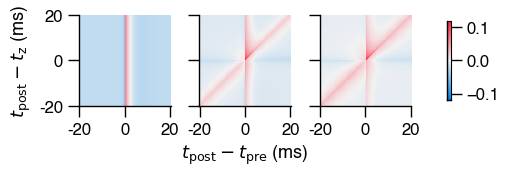

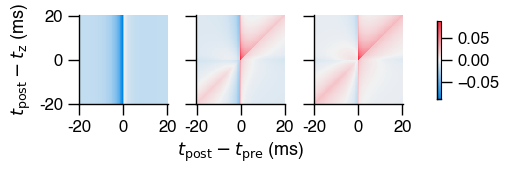

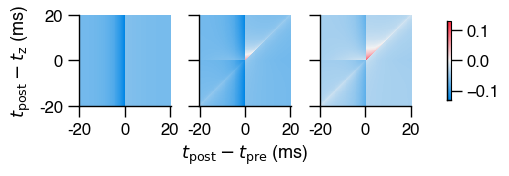

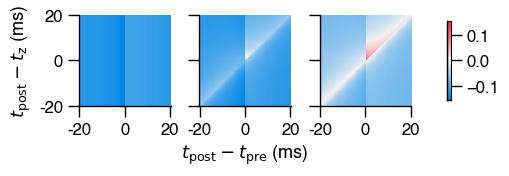

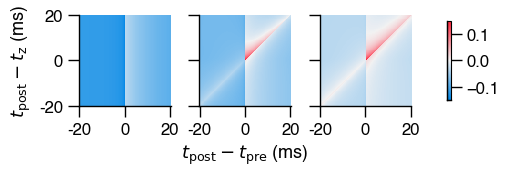

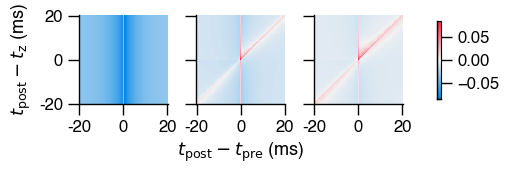

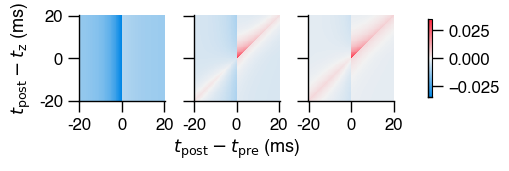

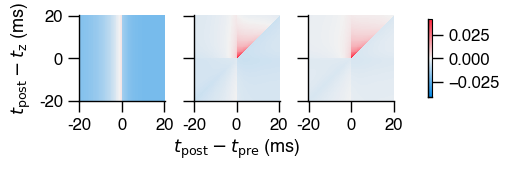

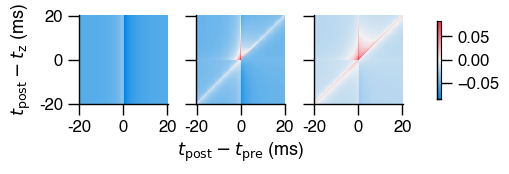

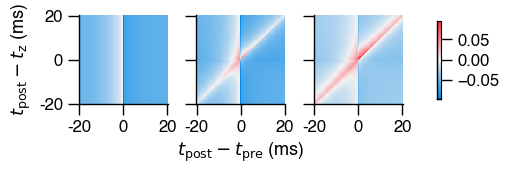

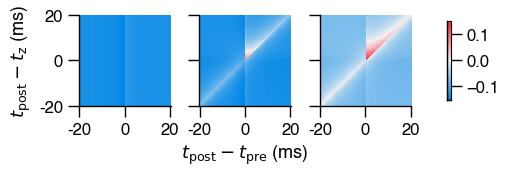

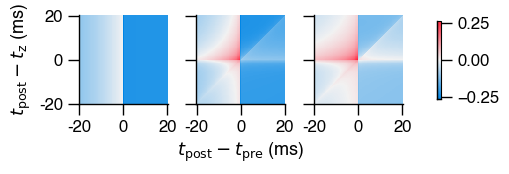

In [19]:
for df in DATA_PATHS_NO_HET_LONG_N5:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=3, scale=1, a_pre=0.3, a_post=0.3, z_max=0.5, z_min=0)

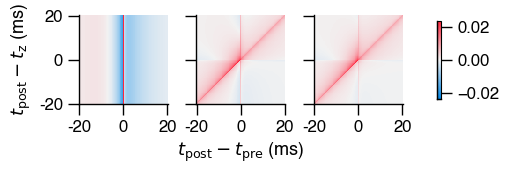

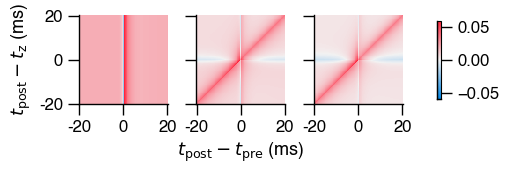

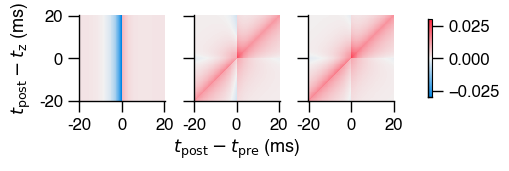

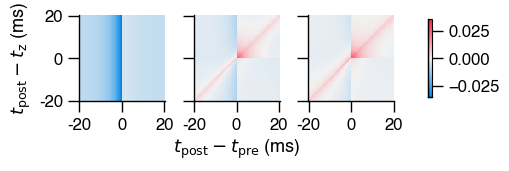

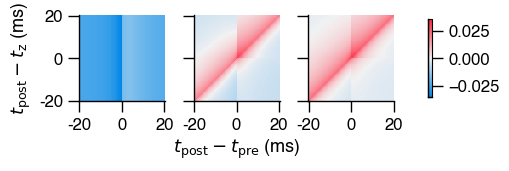

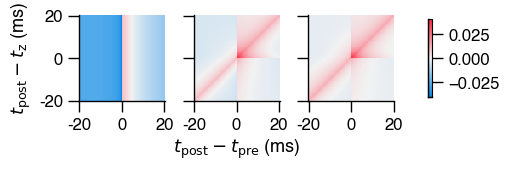

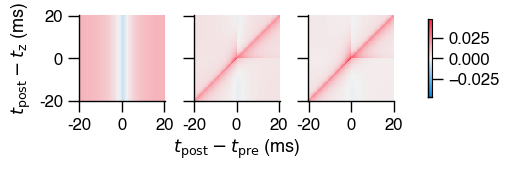

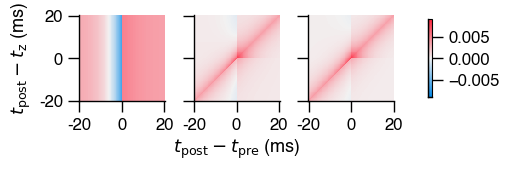

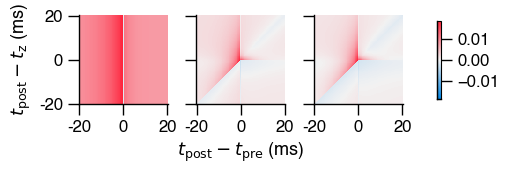

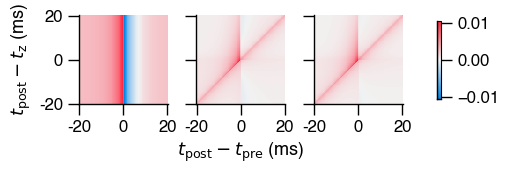

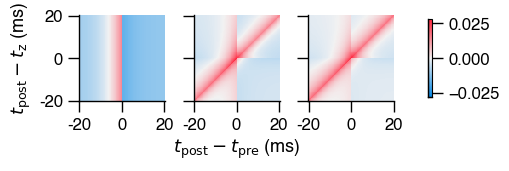

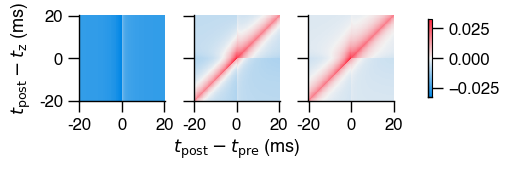

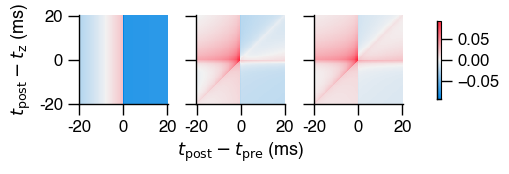

In [49]:
for df in DATA_PATHS_NO_HET_LONG_N5:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=3, scale=1)

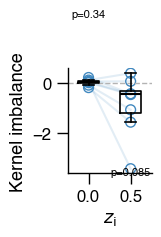

In [34]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_LONG_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=0)
fig.savefig(f'./figures/learning_rules/n5_no_het_long_kernel_asym_w_0.svg')

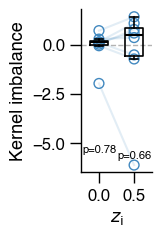

In [37]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_LONG_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=1)
fig.savefig(f'./figures/learning_rules/n5_no_het_long_kernel_asym_w_0.svg')

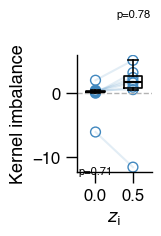

In [35]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_LONG_N5, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=3)
fig.savefig(f'./figures/learning_rules/n5_no_het_long_kernel_asym_w_0.svg')

(<Figure size 525x225 with 4 Axes>,
 array([<Axes: ylabel='$\\dot{w}_{ij}$'>, <Axes: xlabel='$w_{ij}$'>,
        <Axes: >, <Axes: >], dtype=object))

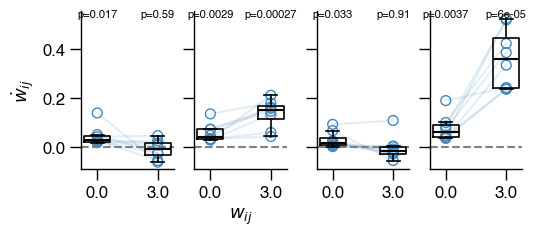

In [36]:
plot_coincident_activity_across_weight(DATA_PATHS_NO_HET_LONG_N5, np.linspace(0, 3, 10), a_pre=0.2, a_post=0.2, z=1)

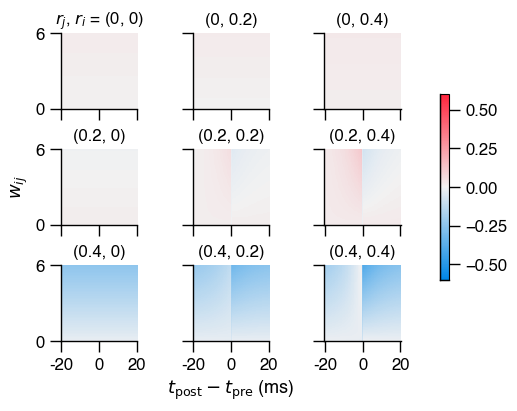

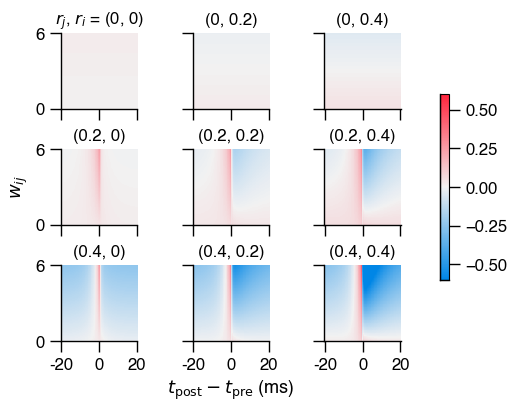

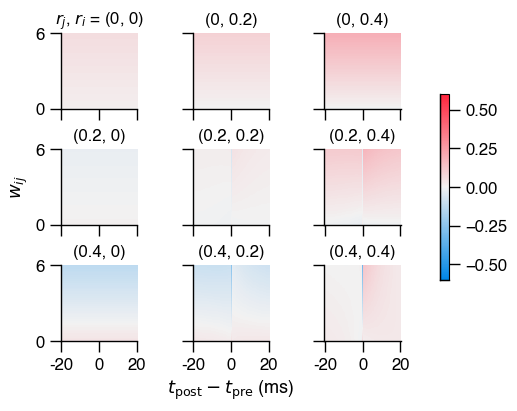

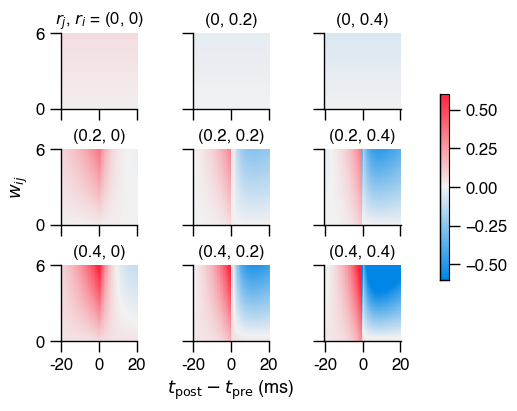

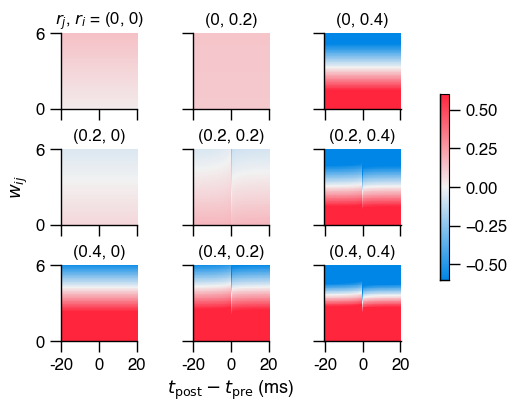

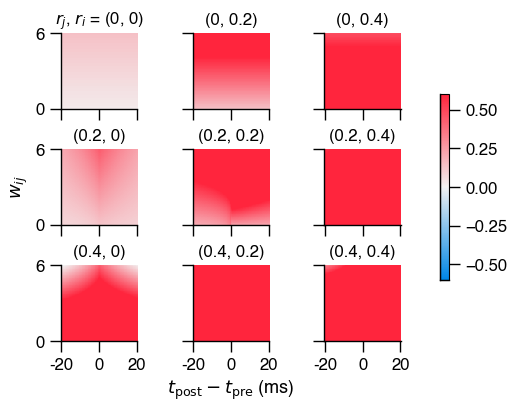

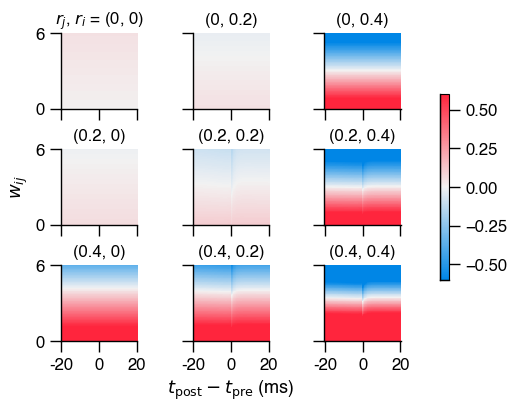

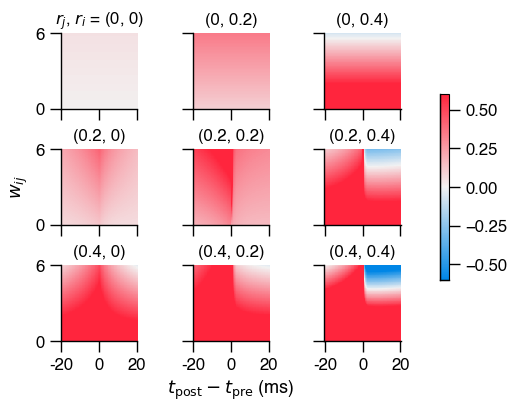

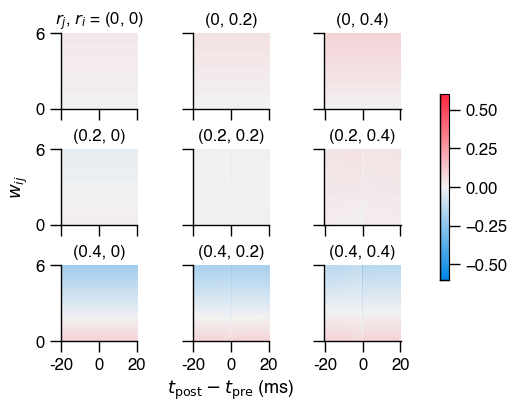

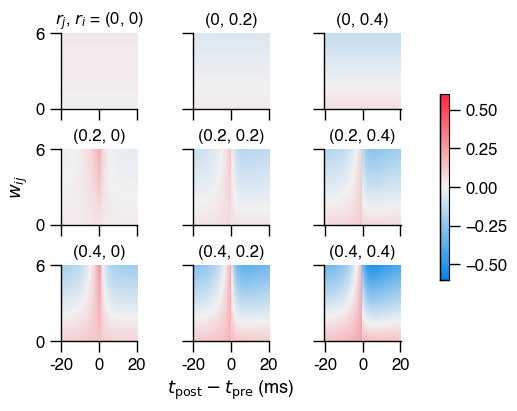

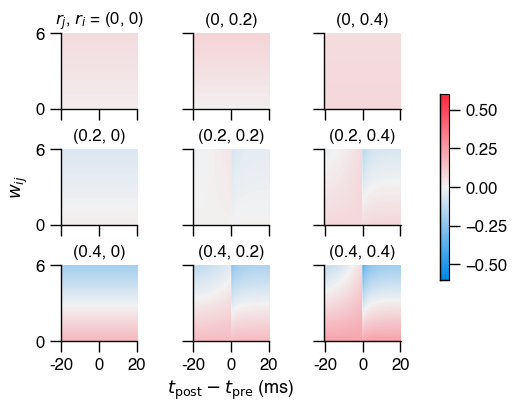

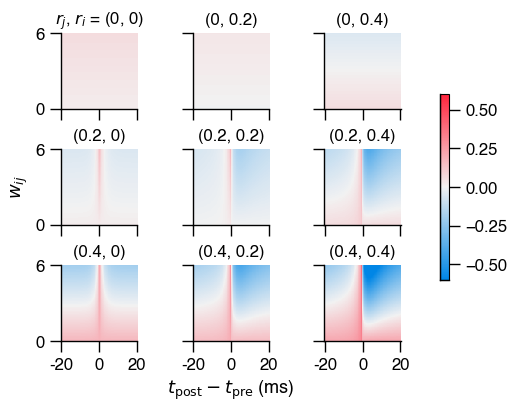

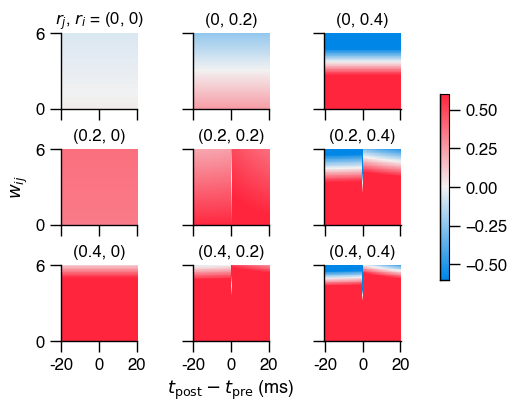

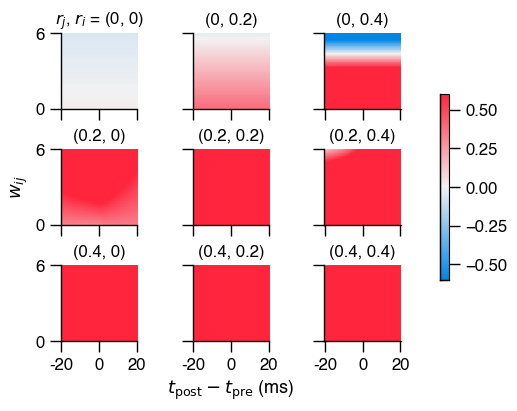

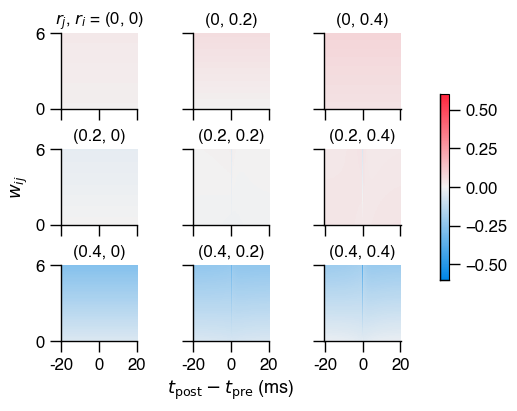

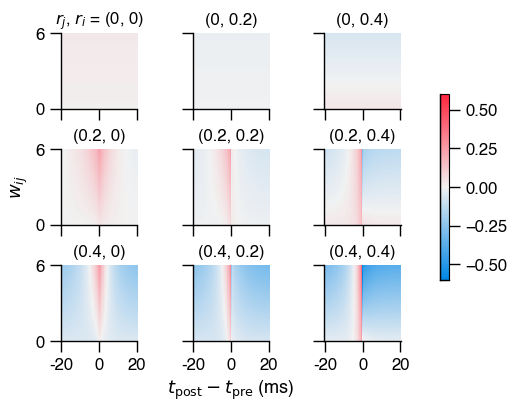

In [18]:
for df in DATA_PATHS_NO_HET_SHORT_2D:
    coefs = load_coefs(df)
    plot_rules_under_input(coefs, z=0, t_lag_post_z=0, v=0.6)
    plot_rules_under_input(coefs, z=1, t_lag_post_z=0, v=0.6)

(8, 4)


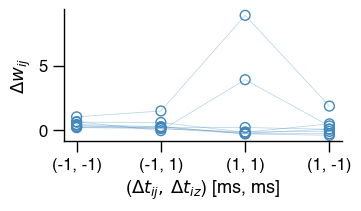

In [39]:
test_time_lags(DATA_PATHS_NO_HET_SHORT_2D, a_pre=0.4, a_post=0.4, z=1, w_ij=6)

(2, 4)


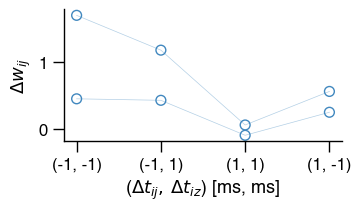

In [42]:
test_time_lags(DATA_PATHS_NO_HET_LONG_2D, a_pre=0.4, a_post=0.4, z=1, w_ij=6)

(3, 4)


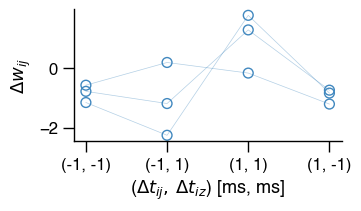

In [41]:
test_time_lags(DATA_PATHS_HET_SHORT_2D, a_pre=0.6, a_post=0.6, z=1, w_ij=6)

(2, 4)


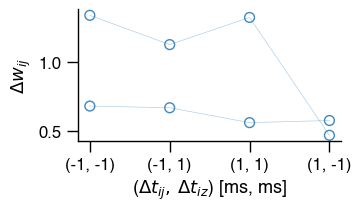

In [43]:
test_time_lags(DATA_PATHS_HET_LONG_2D, a_pre=0.4, a_post=0.4, z=1, w_ij=6)

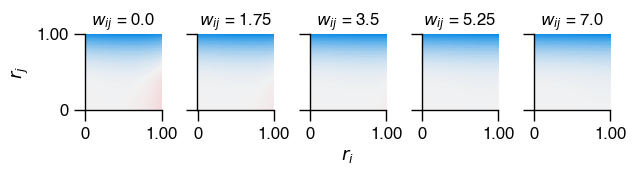

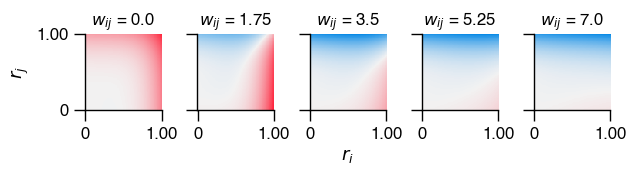

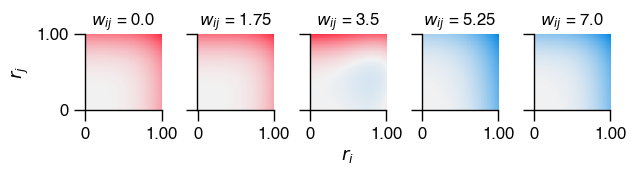

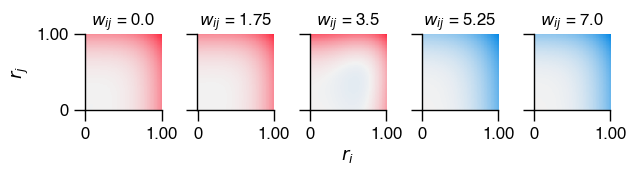

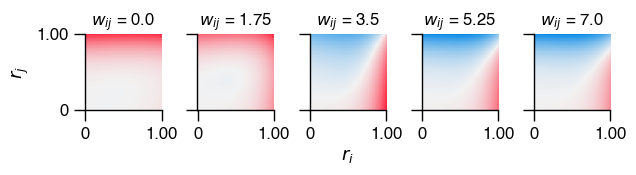

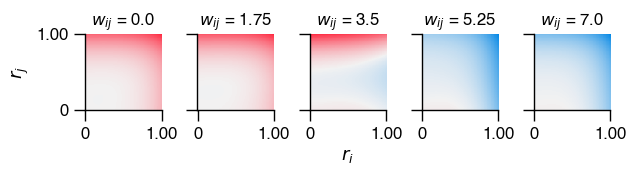

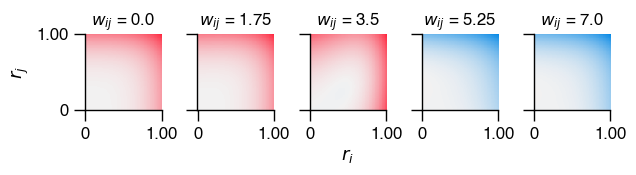

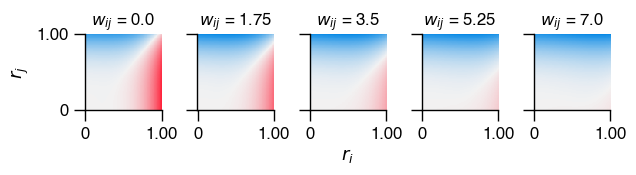

In [19]:
for df in DATA_PATHS_NO_HET_SHORT_2D:
    coefs = load_coefs(df)
    w = np.linspace(0, 7, 5)
    a_pre = np.linspace(0, 1, 100)
    a_post = np.linspace(0, 1, 100)
    compute_weight_change_for_steady_state_firing(coefs, a_pre, a_post, w)

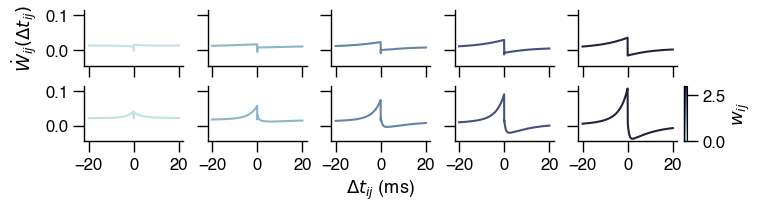

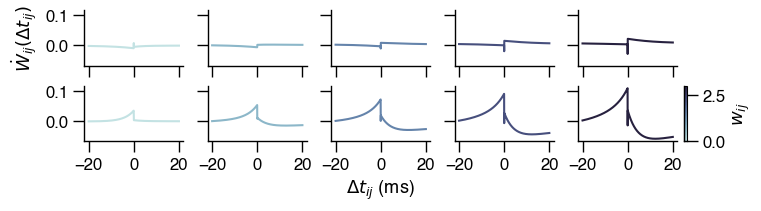

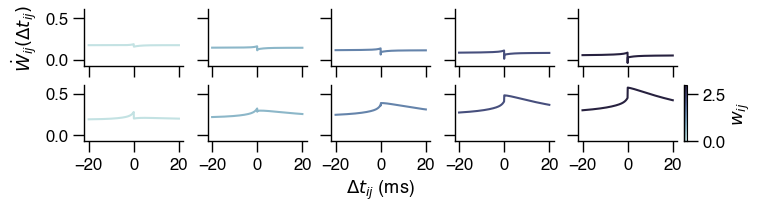

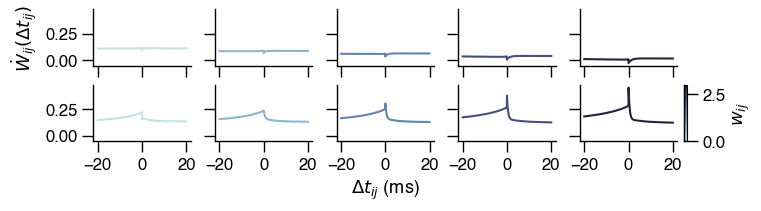

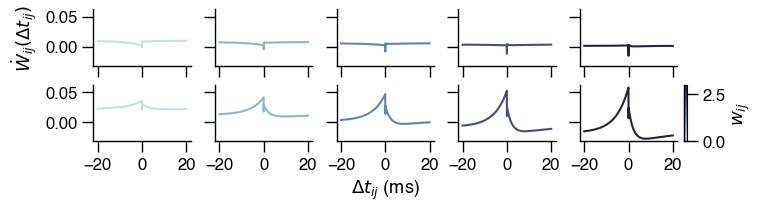

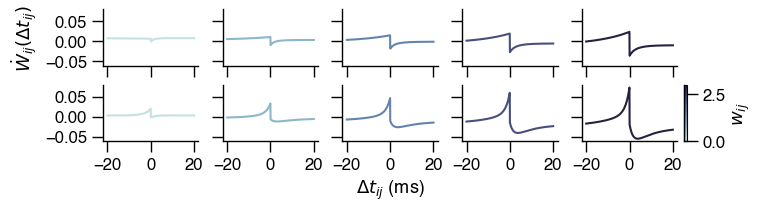

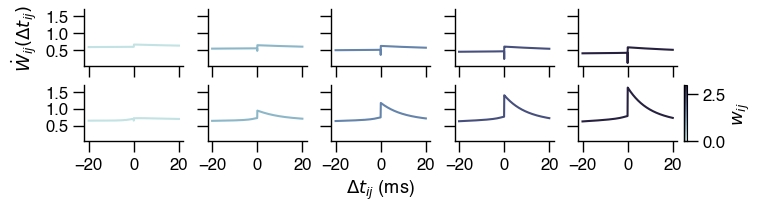

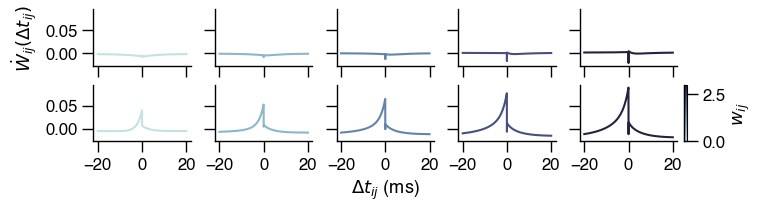

In [20]:
plot_kernels_across_weight(DATA_PATHS_NO_HET_SHORT_2D, zs=[0, 0.5])

/tmp/ipykernel_1988837/3256307117.py:2: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(f'./figures/learning_rules/2d_no_het_short_kernel_asym_w_0.svg')
/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/mmfs1/gscratch/labfairhall/davidgbe/miniconda3/envs/cont_attractor/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


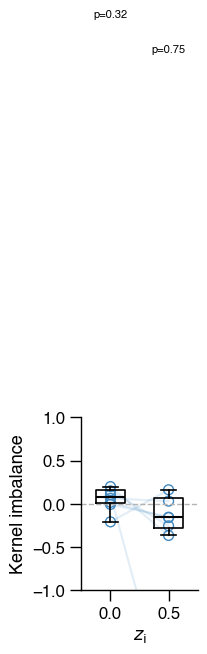

In [27]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_SHORT_2D, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=0, ylim=(-1, 1))
fig.savefig(f'./figures/learning_rules/2d_no_het_short_kernel_asym_w_0.svg')

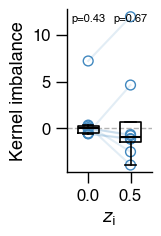

In [26]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_SHORT_2D, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=1)
fig.savefig(f'./figures/learning_rules/2d_no_het_short_kernel_asym_w_1.svg')

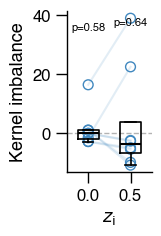

In [28]:
fig, axs = plot_all_kernels_across_z(DATA_PATHS_NO_HET_SHORT_2D, z=np.linspace(0, 0.5, 10), t_lags=[30e-3], w_ij=5)
fig.savefig(f'./figures/learning_rules/2d_no_het_short_kernel_asym_w_5.svg')

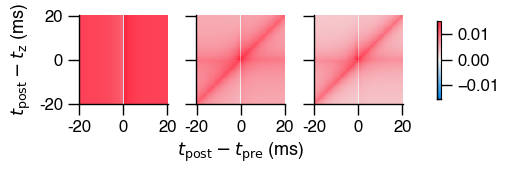

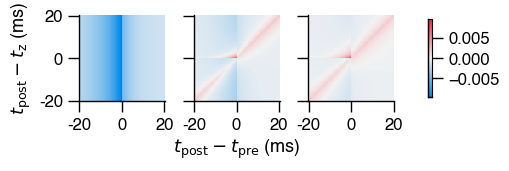

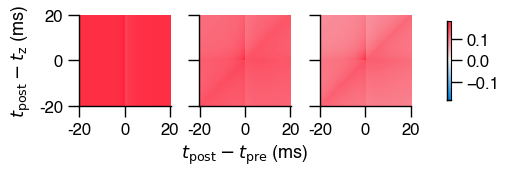

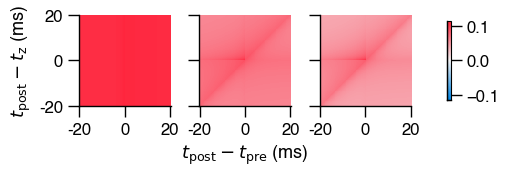

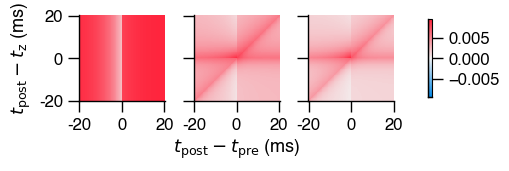

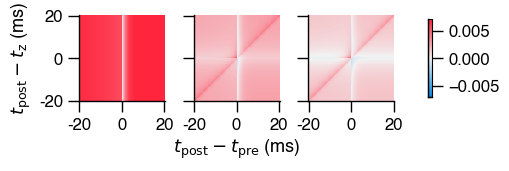

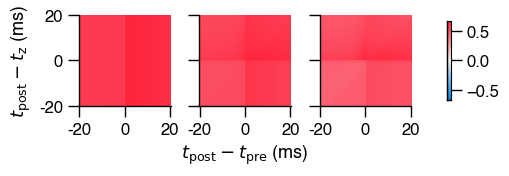

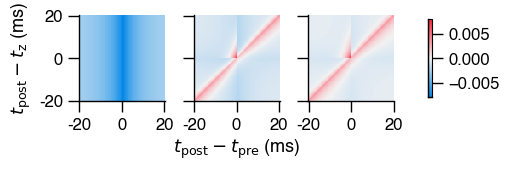

In [30]:
for df in DATA_PATHS_NO_HET_SHORT_2D:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=0)

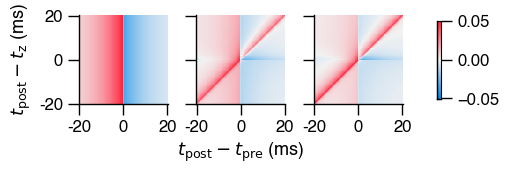

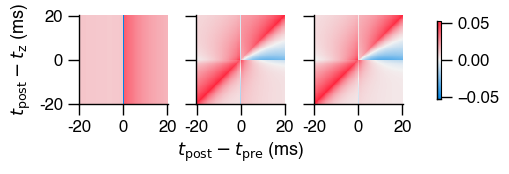

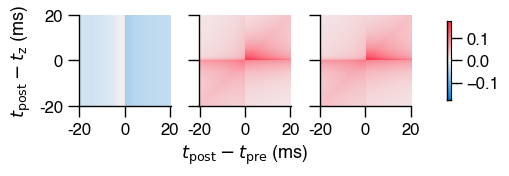

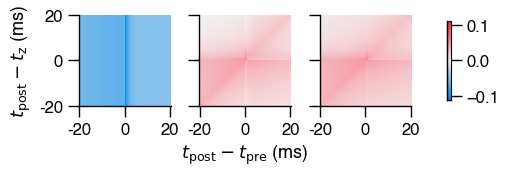

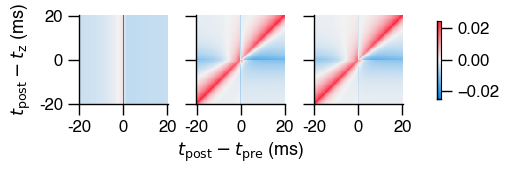

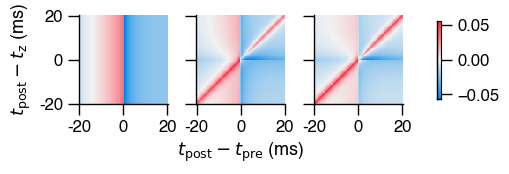

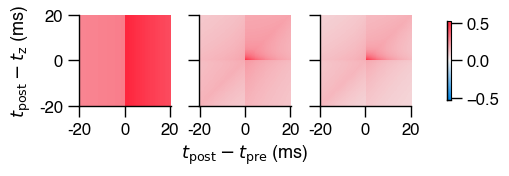

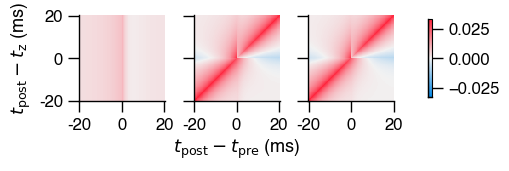

In [38]:
for df in DATA_PATHS_NO_HET_SHORT_2D:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=5)

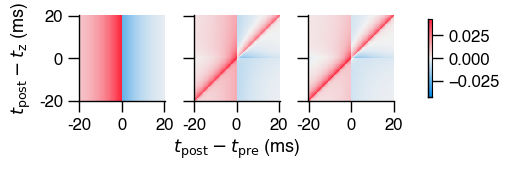

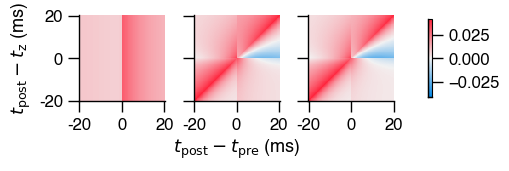

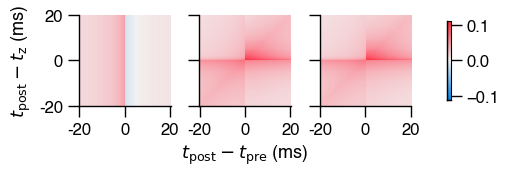

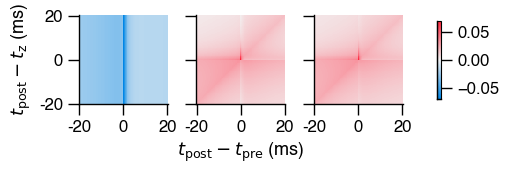

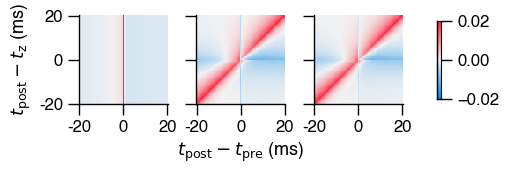

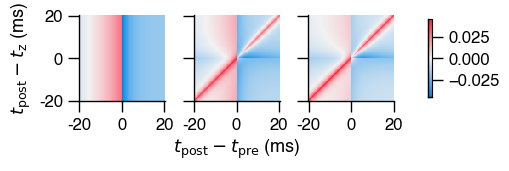

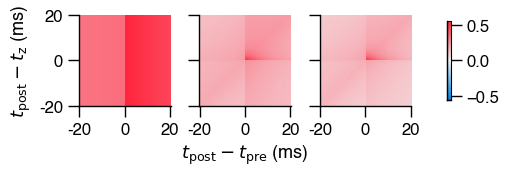

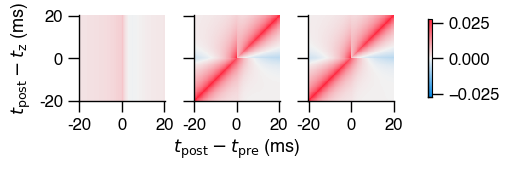

In [33]:
for df in DATA_PATHS_NO_HET_SHORT_2D:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=4)

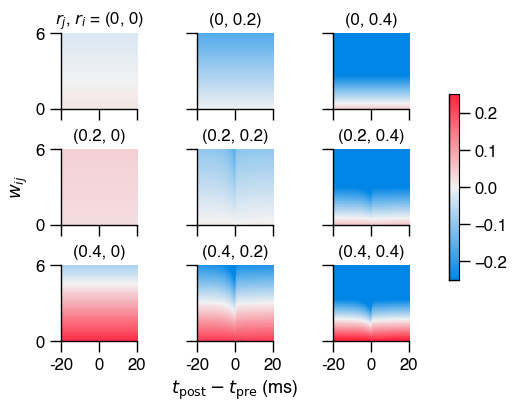

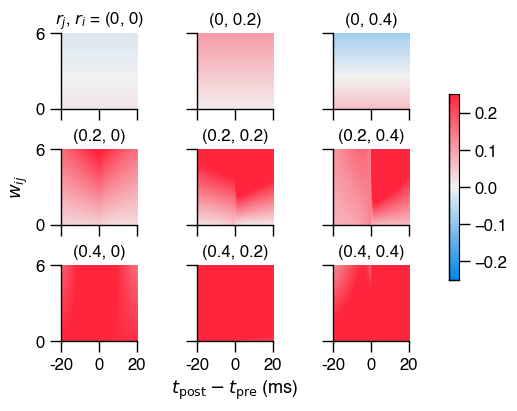

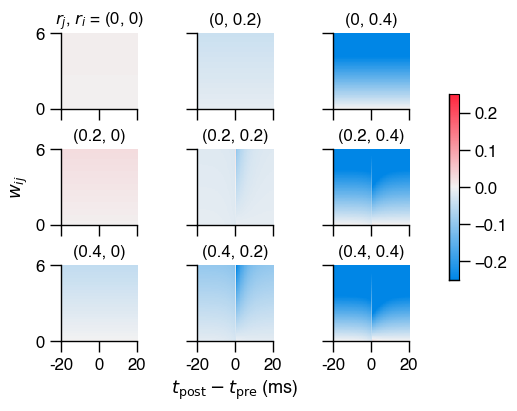

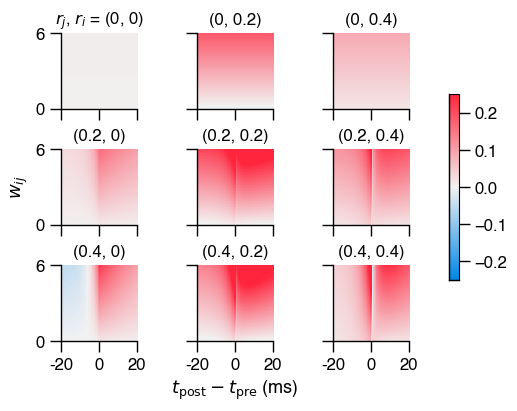

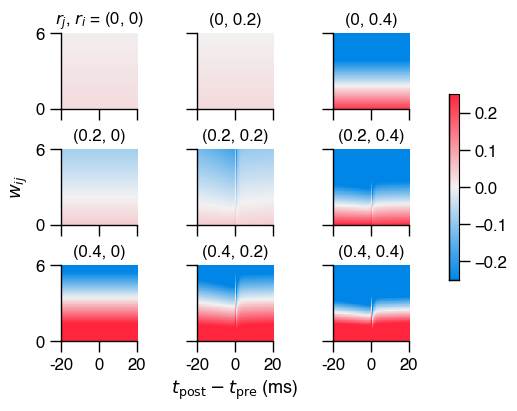

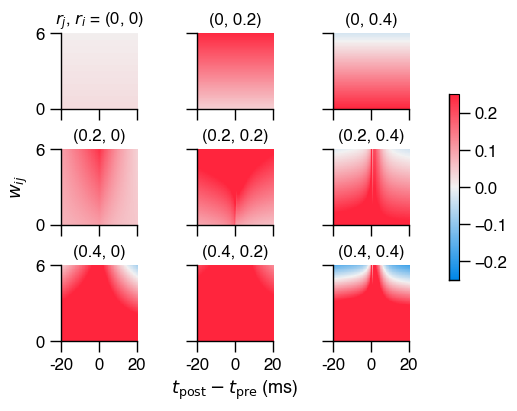

In [34]:
for df in DATA_PATHS_HET_SHORT_2D:
    coefs = load_coefs(df)
    plot_rules_under_input(coefs, z=0, t_lag_post_z=0, v=0.25)
    plot_rules_under_input(coefs, z=0.5, t_lag_post_z=0, v=0.25)

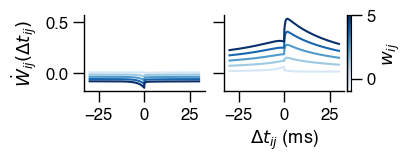

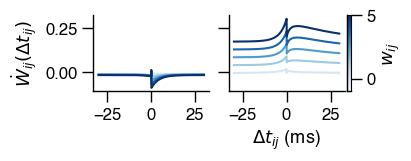

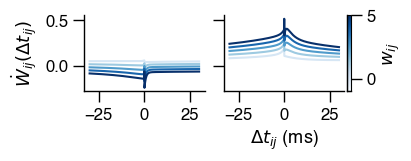

In [50]:
plot_kernels_across_weight(DATA_PATHS_HET_SHORT_2D, zs=[0, 0.5])

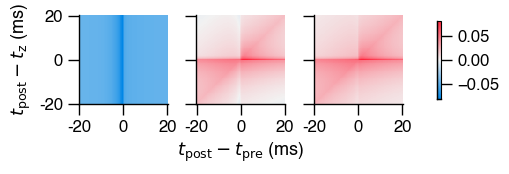

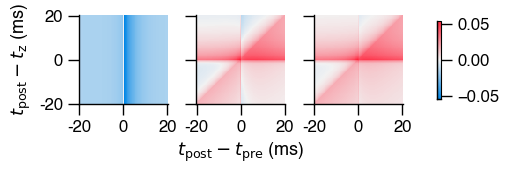

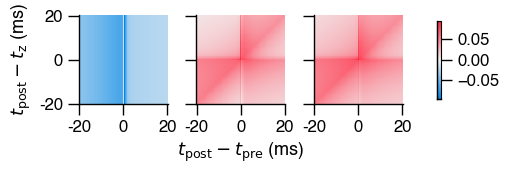

In [38]:
for df in DATA_PATHS_HET_SHORT_2D:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=3)

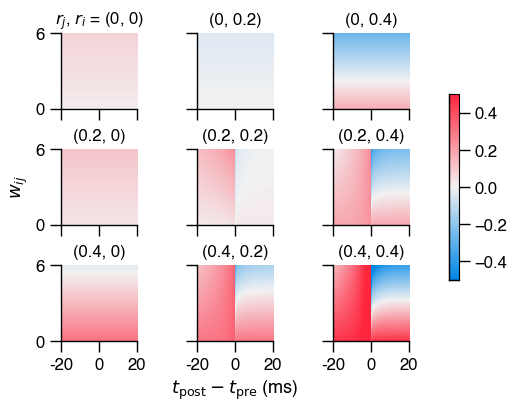

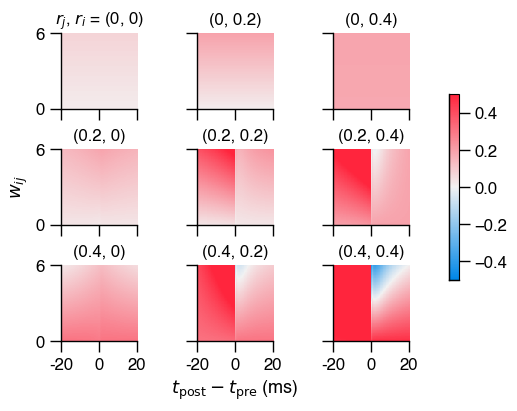

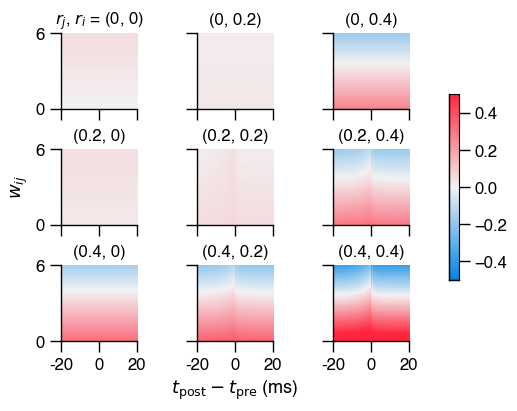

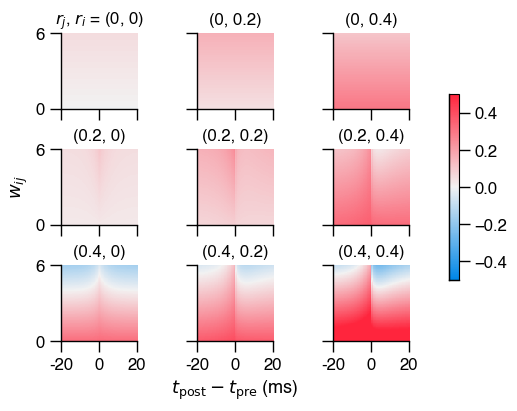

In [36]:
for df in DATA_PATHS_NO_HET_LONG_2D:
    coefs = load_coefs(df)
    plot_rules_under_input(coefs, z=0, t_lag_post_z=0, v=0.5)
    plot_rules_under_input(coefs, z=0.5, t_lag_post_z=0, v=0.5)

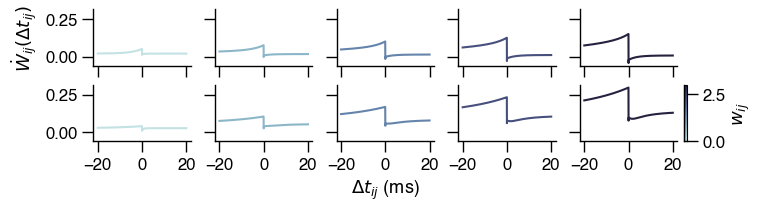

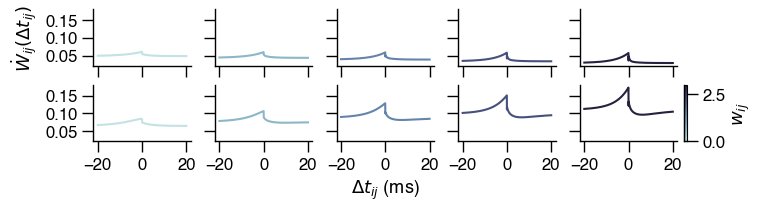

In [37]:
plot_kernels_across_weight(DATA_PATHS_NO_HET_LONG_2D, zs=[0, 0.5])

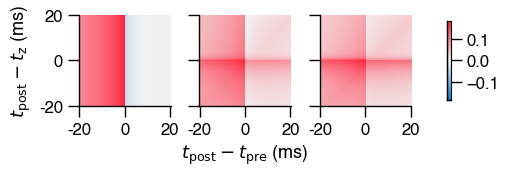

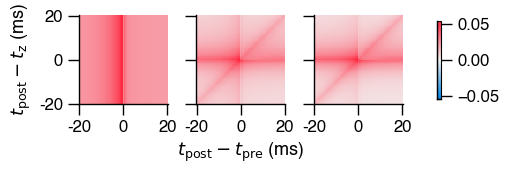

In [40]:
for df in DATA_PATHS_NO_HET_LONG_2D:
    coefs = load_coefs(df)
    plot_rules_vary_z(coefs, w_ij=4)

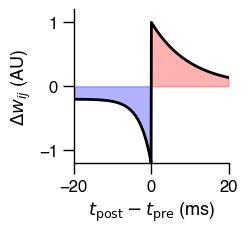

In [7]:
# --- STDP kernel function ---
def stdp_kernel(dt, A_plus=1.0, tau_plus=10.0, A_minus=1.0, tau_minus=3.0):
    """
    Typical exponential STDP kernel
    dt: post - pre (ms)
    """
    dw = np.zeros_like(dt)
    dw[dt > 0] = A_plus * np.exp(-dt[dt > 0] / tau_plus)        # LTP
    dw[dt < 0] = -(A_minus * np.exp(dt[dt < 0] / tau_minus) + 0.2)      # LTD
    return dw

# --- time axis ---
dt = np.linspace(-20, 20, 500)
dw = stdp_kernel(dt)

# --- plot ---
fig, ax = plt.subplots(figsize=(2, 2))
ax.plot(dt, dw, color='k', linewidth=2, label='STDP kernel')
ax.set_xlabel(r'$t_{\rm post} - t_{\rm pre}$ (ms)')
ax.set_ylabel(r'$\Delta w_{ij}$ (AU)')
# ax.axhline(0, color='0.5', linestyle='--')

cutoff = 20

# --- color regions ---
# Red: 0 < dt < 10 ms under curve
ax.fill_between(dt, 0, dw, where=(dt > 0) & (dt < cutoff) & (dw > 0),
                color='red', alpha=0.3)
# Blue: -10 < dt < 0 ms above curve but below 0
ax.fill_between(dt, 0, dw, where=(dt > -cutoff) & (dt < 0) & (dw < 0),
                color='blue', alpha=0.3)

ax.set_xlim(-20, 20)
ax.set_ylim(-1.2, 1.2)
format_plot(ax)
fig.savefig('./figures/learning_rules/kernel_asym_demo_sketch.svg')